## Imports and Paths Configurations

In [59]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

In [60]:
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '0955'

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# sequence_id = '0955'
frame_idx = 0

## Example Sequence From the Data

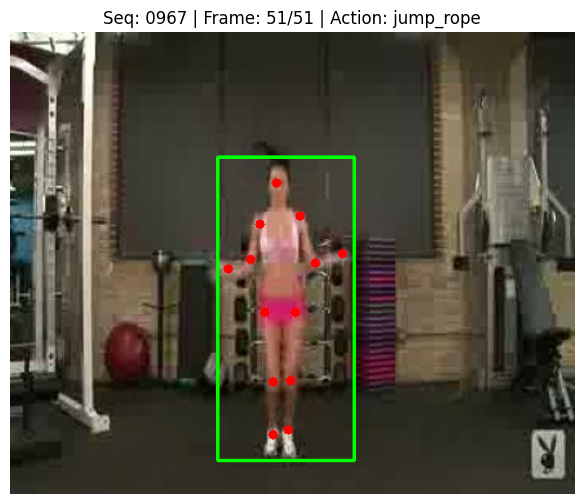

In [76]:
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '0967'

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# sequence_id = '0955'
frame_idx = 0


# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]
action_name = mat_data['action'][0]

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

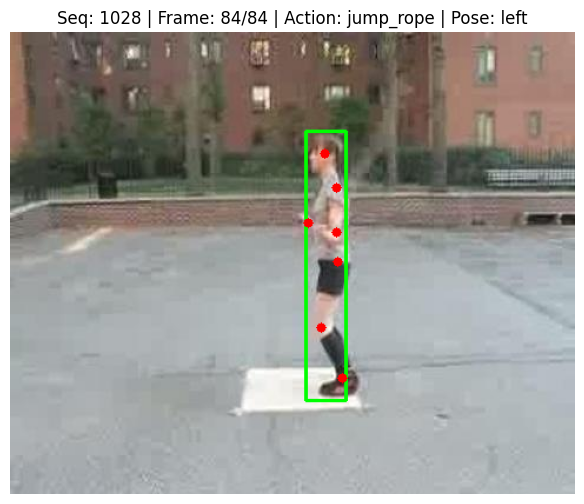

In [121]:
# ... (Keep your imports and path setups the same) ...
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '1028'  # Change to your desired sequence ID 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

# Feature Extraction Example

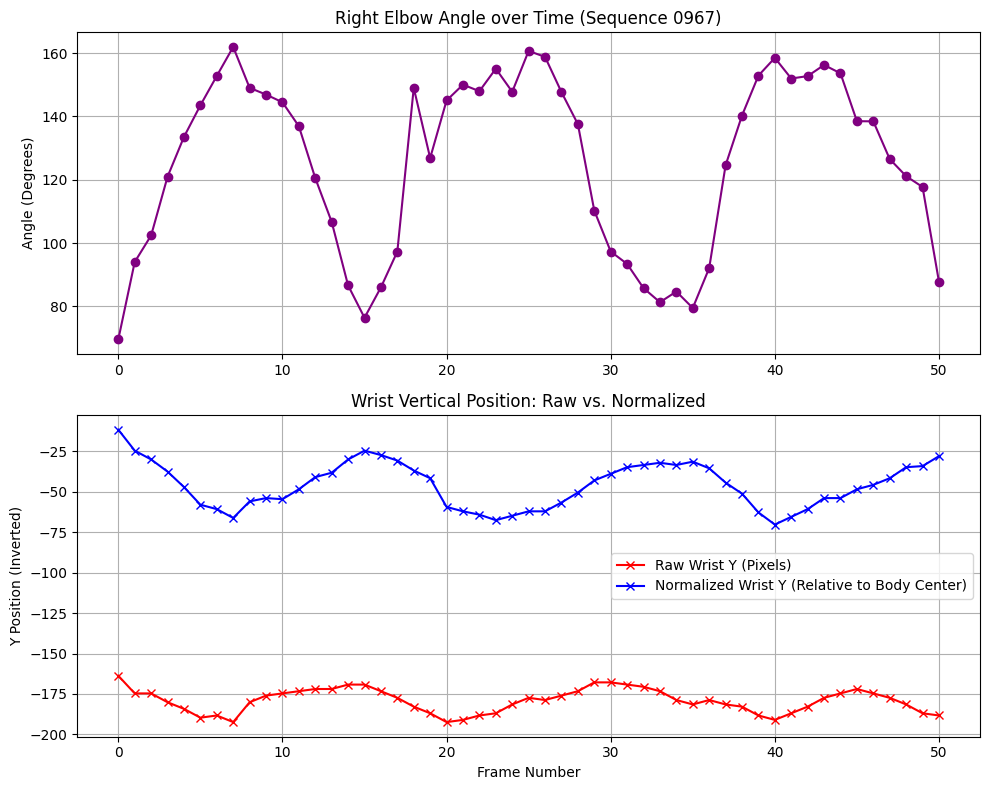

In [115]:
import os
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Feature Extraction Functions ---

def calculate_angle(pt1, pt2, pt3):
    """Calculates the angle at pt2 given three 2D points (x, y)."""
    v1 = np.array(pt1) - np.array(pt2)
    v2 = np.array(pt3) - np.array(pt2)
    
    # Handle overlapping points to avoid division by zero
    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
        return 0.0
        
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))

def normalize_pose(joints_x, joints_y, visibility):
    """Centers the pose based on the midpoint of the shoulders."""
    norm_x = np.zeros_like(joints_x, dtype=float)
    norm_y = np.zeros_like(joints_y, dtype=float)
    
    # Indices: 1=L_Sho, 2=R_Sho, 0=Head
    if visibility[1] == 1 and visibility[2] == 1:
        center_x = (joints_x[1] + joints_x[2]) / 2.0
        center_y = (joints_y[1] + joints_y[2]) / 2.0
    elif visibility[0] == 1: 
        center_x, center_y = joints_x[0], joints_y[0]
    else:
        return joints_x, joints_y # Cannot normalize
        
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            norm_x[i] = joints_x[i] - center_x
            norm_y[i] = joints_y[i] - center_y
            
    return norm_x, norm_y

# --- 2. Load Data for a specific sequence ---
DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '0967' # Using one of your 'Front' view sequences
mat_data = sio.loadmat(os.path.join(LABELS_DIR, f'{sequence_id}.mat'))
n_frames = mat_data['nframes'][0][0]

# Lists to store our extracted features over time
frames_valid = []
right_elbow_angles = []
raw_wrist_y = []
normalized_wrist_y = []

# --- 3. Extract Features Frame by Frame ---
for frame_idx in range(n_frames):
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    vis = mat_data['visibility'][frame_idx]
    
    # Get normalized coordinates
    norm_x, norm_y = normalize_pose(joints_x, joints_y, vis)
    
    # Penn Action Indices: 2:R_Sho, 4:R_Elb, 6:R_Wri
    if vis[2] == 1 and vis[4] == 1 and vis[6] == 1:
        pt1 = (joints_x[2], joints_y[2])
        pt2 = (joints_x[4], joints_y[4])
        pt3 = (joints_x[6], joints_y[6])
        
        angle = calculate_angle(pt1, pt2, pt3)
        
        frames_valid.append(frame_idx)
        right_elbow_angles.append(angle)
        
        # In images, Y goes down. We invert it (* -1) so 'higher up' looks higher on the graph
        raw_wrist_y.append(joints_y[6] * -1) 
        normalized_wrist_y.append(norm_y[6] * -1)

# --- 4. Plot the Results ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Elbow Angle
ax1.plot(frames_valid, right_elbow_angles, marker='o', color='purple')
ax1.set_title(f'Right Elbow Angle over Time (Sequence {sequence_id})')
ax1.set_ylabel('Angle (Degrees)')
ax1.grid(True)

# Plot 2: Raw vs Normalized Wrist Y-Position
ax2.plot(frames_valid, raw_wrist_y, label='Raw Wrist Y (Pixels)', marker='x', color='red')
ax2.plot(frames_valid, normalized_wrist_y, label='Normalized Wrist Y (Relative to Body Center)', marker='x', color='blue')
ax2.set_title('Wrist Vertical Position: Raw vs. Normalized')
ax2.set_xlabel('Frame Number')
ax2.set_ylabel('Y Position (Inverted)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Jump-Rope Feature Extraction

#### 1. Normalized Joint Positions (`norm_r_wrist_y`, `norm_l_wrist_y`)
* **What it is:** We shift the origin point `(0,0)` of the coordinate system from the top-left corner of the video to the center of the person's shoulders/neck. The normalized coordinates represent where the wrists are relative to the person's torso.
* **How it's calculated (Code Logic):** We first find the `center_x` and `center_y` by averaging the Left Shoulder (1) and Right Shoulder (2) coordinates: `center_x = (joints_x[1] + joints_x[2]) / 2.0`. Then, we loop through all visible joints and subtract this center point from their raw coordinates: `norm_x[i] = joints_x[i] - center_x`.
* **How it helps:** This provides **Translation Invariance**. If a person jumps up in the video, their raw wrist Y-coordinate goes up—even if they didn't move their arms! By normalizing the position relative to the shoulders, the model ignores the body's overall bouncing and only sees the rhythmic, circular motion of the wrists required to swing the rope.

#### 2. Joint Angles (`r_elbow_angle`, `l_elbow_angle`, `r_knee_angle`, `l_knee_angle`)
* **What it is:** The mathematical angle (in degrees, from 0 to 180) formed by three connected joints. For example, the elbow angle is the angle between the Shoulder, Elbow, and Wrist.
* **How it's calculated (Code Logic):** We use the **Dot Product** of two vectors. We create Vector 1 (Elbow to Shoulder) and Vector 2 (Elbow to Wrist). We calculate the dot product of these vectors and divide it by the product of their magnitudes (lengths) using `np.linalg.norm()`. Finally, we use the inverse cosine function (`np.arccos`) to get the angle in radians, and convert it to degrees.
* **How it helps:** Angles give the model a perfect understanding of posture, completely independent of the camera scale (whether the person is close to the camera or far away).
    * **Elbow Angles:** In jump rope, the elbows stay bent and locked at the sides (usually between 60° and 90°). This easily distinguishes jump rope from actions like "tennis serve" or "baseball pitch," where the arm fully extends to 180°.
    * **Knee Angles:** Captures the deepness of the jump. As the person prepares to jump, the knee angle drops, and as they push off the ground, it extends. This rhythm is the heartbeat of a jump rope action.

#### 3. Geometric Distances (`r_wrist_to_hip_dist`, `l_wrist_to_hip_dist`, `ankles_dist`)
* **What it is:** The straight-line Euclidean distance between two specific joints on the normalized skeleton.
* **How it's calculated (Code Logic):** We use the standard Euclidean distance formula: $\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$. In Python, this is calculated instantly using NumPy's vector norm: `np.linalg.norm(np.array(pt1) - np.array(pt2))`.
* **How it helps:** This defines the spatial boundaries of the action.
    * **Wrist-to-Hip:** When jumping rope, a person's hands naturally hover right around hip level to spin the rope efficiently. If this distance gets massive, the model knows they are reaching up (e.g., "Pull-ups" or "Basketball shoot").
    * **Ankles Distance:** Jumpers keep their feet close together. If the ankle distance suddenly gets very wide, the model immediately knows the action is more likely to be a "Jumping Jack" or a "Squat."

#### 4. Joint Velocities (`r_wrist_vel_y`, `l_wrist_vel_y`)
* **What it is:** The difference in the Y-position of the wrist between the current frame and the previous frame. It tells us how fast and in what direction (up or down) the joint is moving.
* **How it's calculated (Code Logic):** During our frame loop, we save the wrist's normalized Y-coordinate at the end of each iteration into a variable like `prev_r_wrist_y`. On the next frame, we calculate velocity by simple subtraction: `velocity_y = current_norm_y - prev_r_wrist_y`.
* **How it helps:** Actions are defined by motion, not just static poses. Velocity solves the problem of speed variance (someone jumping very slow vs. very fast). Instead of trying to memorize positions, the AI learns the rhythmic acceleration and deceleration patterns of the hands spinning the rope.

#### 5. Viewpoint Imputation (Data Cleaning Step)
* **What it is:** A preprocessing step where we identify side-view cameras (e.g., `right_side`) and copy the visible joints over to the occluded (hidden) side.
* **How it's calculated (Code Logic):** We check the `viewpoint` label provided in the dataset. If it says `'right'`, we know the left side is likely blocked by the body. We loop through the corresponding left and right indices. If a right joint is visible (`vis[r] == 1`) but the left is missing (`vis[l] == 0`), we overwrite the left coordinates: `jx[l] = jx[r]`, `jy[l] = jy[r]`, and set `vis[l] = 1`.
* **How it helps:** Machine Learning models hate missing data (`NaN` or `0.0` where a joint should be). Because jump rope is a symmetrical action (both sides of the body do the same thing), copying the right arm to the left arm in a right-profile video saves the math from crashing and ensures the model gets consistent, unbroken data streams to learn from.

In [120]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- 1. Helper Functions ---

def calculate_angle(pt1, pt2, pt3):
    """Calculates the angle at pt2 given three 2D points."""
    v1 = np.array(pt1) - np.array(pt2)
    v2 = np.array(pt3) - np.array(pt2)
    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0: return 0.0
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def calculate_distance(pt1, pt2):
    """Calculates Euclidean distance between two points."""
    return np.linalg.norm(np.array(pt1) - np.array(pt2))

def normalize_pose(joints_x, joints_y, visibility):
    """Centers the pose based on the midpoint of the shoulders/neck."""
    norm_x, norm_y = np.zeros_like(joints_x, dtype=float), np.zeros_like(joints_y, dtype=float)
    if visibility[1] == 1 and visibility[2] == 1:
        center_x, center_y = (joints_x[1] + joints_x[2]) / 2.0, (joints_y[1] + joints_y[2]) / 2.0
    elif visibility[0] == 1: 
        center_x, center_y = joints_x[0], joints_y[0]
    else:
        return joints_x, joints_y 
        
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            norm_x[i], norm_y[i] = joints_x[i] - center_x, joints_y[i] - center_y
    return norm_x, norm_y

def impute_side_views(jx, jy, vis, viewpoint):
    """Copies visible joints to the missing side for side-view videos."""
    # Penn Action Indices: [Sho, Elb, Wri, Hip, Kne, Ank]
    left_indices  = [1, 3, 5, 7, 9, 11]
    right_indices = [2, 4, 6, 8, 10, 12]
    
    # If viewpoint is right, the left side is often occluded. Copy Right -> Left
    if viewpoint in ['right', 'right_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[r] == 1 and vis[l] == 0:
                jx[l], jy[l], vis[l] = jx[r], jy[r], 1
                
    # If viewpoint is left, the right side is often occluded. Copy Left -> Right
    elif viewpoint in ['left', 'left_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[l] == 1 and vis[r] == 0:
                jx[r], jy[r], vis[r] = jx[l], jy[l], 1
                
    return jx, jy, vis


# --- 2. Extract Features Loop ---
all_features = []

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    sequence_id = label_file.split('.')[0]
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'jump_rope': continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: viewpoint = viewpoint[0]
    
    # Variables to track previous frame for velocity
    prev_r_wrist_y = None
    prev_l_wrist_y = None
    
    for frame_idx in range(n_frames):
        # 1. Load Raw Frame Data
        joints_x = mat_data['x'][frame_idx].astype(float)
        joints_y = mat_data['y'][frame_idx].astype(float)
        vis = mat_data['visibility'][frame_idx].copy()
        
        # 2. Impute missing side joints and Normalize
        joints_x, joints_y, vis = impute_side_views(joints_x, joints_y, vis, viewpoint)
        norm_x, norm_y = normalize_pose(joints_x, joints_y, vis)
        
        # 3. Calculate Angles
        r_elbow_angle = calculate_angle((norm_x[2], norm_y[2]), (norm_x[4], norm_y[4]), (norm_x[6], norm_y[6])) if (vis[2] and vis[4] and vis[6]) else 0.0
        l_elbow_angle = calculate_angle((norm_x[1], norm_y[1]), (norm_x[3], norm_y[3]), (norm_x[5], norm_y[5])) if (vis[1] and vis[3] and vis[5]) else 0.0
        r_knee_angle = calculate_angle((norm_x[8], norm_y[8]), (norm_x[10], norm_y[10]), (norm_x[12], norm_y[12])) if (vis[8] and vis[10] and vis[12]) else 0.0
        l_knee_angle = calculate_angle((norm_x[7], norm_y[7]), (norm_x[9], norm_y[9]), (norm_x[11], norm_y[11])) if (vis[7] and vis[9] and vis[11]) else 0.0
        
        # 4. Calculate Distances
        r_wrist_to_hip = calculate_distance((norm_x[6], norm_y[6]), (norm_x[8], norm_y[8])) if (vis[6] and vis[8]) else 0.0
        l_wrist_to_hip = calculate_distance((norm_x[5], norm_y[5]), (norm_x[7], norm_y[7])) if (vis[5] and vis[7]) else 0.0
        ankles_dist = calculate_distance((norm_x[11], norm_y[11]), (norm_x[12], norm_y[12])) if (vis[11] and vis[12]) else 0.0
        
        # 5. Calculate Velocities
        r_wrist_vel_y = (norm_y[6] - prev_r_wrist_y) if (prev_r_wrist_y is not None and vis[6]) else 0.0
        l_wrist_vel_y = (norm_y[5] - prev_l_wrist_y) if (prev_l_wrist_y is not None and vis[5]) else 0.0
        
        # Update previous frame trackers
        prev_r_wrist_y = norm_y[6] if vis[6] else None
        prev_l_wrist_y = norm_y[5] if vis[5] else None

        # 6. Save to dictionary
        frame_data = {
            'sequence_id': sequence_id,
            'frame_num': frame_idx,
            'viewpoint': viewpoint,
            
            # Normalized Wrist Positions
            'norm_r_wrist_y': norm_y[6] if vis[6] else 0.0,
            'norm_l_wrist_y': norm_y[5] if vis[5] else 0.0,
            
            # Angles
            'r_elbow_angle': r_elbow_angle,
            'l_elbow_angle': l_elbow_angle,
            'r_knee_angle': r_knee_angle,
            'l_knee_angle': l_knee_angle,
            
            # Distances
            'r_wrist_to_hip_dist': r_wrist_to_hip,
            'l_wrist_to_hip_dist': l_wrist_to_hip,
            'ankles_dist': ankles_dist,
            
            # Velocities (Motion)
            'r_wrist_vel_y': r_wrist_vel_y,
            'l_wrist_vel_y': l_wrist_vel_y
        }
        
        all_features.append(frame_data)

# --- 3. Save to Pandas and CSV ---
df_features = pd.DataFrame(all_features)
df_features.to_csv('jump_rope_features.csv', index=False)

print(f"Extraction Complete! Extracted features for {len(df_features)} frames.")
display(df_features.head(100))

Extraction Complete! Extracted features for 3642 frames.


,sequence_id,frame_num,viewpoint,norm_r_wrist_y,norm_l_wrist_y,r_elbow_angle,l_elbow_angle,r_knee_angle,l_knee_angle,r_wrist_to_hip_dist,l_wrist_to_hip_dist,ankles_dist,r_wrist_vel_y,l_wrist_vel_y
0,0955,0,front,41.619792,40.255208,156.434604,110.123451,174.451156,173.621466,26.212790,36.051868,16.878964,0.000000,0.000000e+00
1,0955,1,front,45.713542,42.984375,149.193505,124.722312,177.568307,177.563352,22.380831,33.564312,15.256505,4.093750,2.729167e+00
2,0955,2,front,48.442708,47.078125,152.315636,136.675990,177.496687,178.781125,22.003245,30.665196,15.558644,2.729167,4.093750e+00
3,0955,3,front,55.947917,54.583333,160.346176,143.350753,177.632531,178.806511,22.213807,35.896583,15.256505,7.505208,7.505208e+00
4,0955,4,front,57.994792,59.359375,161.053495,157.011283,176.423666,177.442583,23.197917,34.114583,17.948291,2.046875,4.776042e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0957,10,front,44.348958,40.255208,105.685906,104.356776,175.604840,178.420517,62.726320,59.496459,17.791990,-4.093750,-5.458333e+00
96,0957,11,front,45.713542,40.255208,108.650693,112.094230,174.986886,175.770391,57.003009,51.872119,13.916074,1.364583,2.842171e-14
97,0957,12,front,51.854167,42.302083,112.554845,109.840698,175.683972,176.907117,58.867182,55.261413,15.256505,6.140625,2.046875e+00
98,0957,13,front,50.489583,46.395833,112.263995,115.135703,179.532017,175.446232,55.075773,52.655945,13.916074,-1.364583,4.093750e+00


# Jump Rope Feature Extraction after Edit


#### 1. Normalized Joint Positions (`norm_r_wrist_y`, `norm_l_wrist_y`)
* **What it is:** We shift the origin point `(0,0)` of the coordinate system from the top-left corner of the video to the center of the person's shoulders/neck. The normalized coordinates represent where the wrists are relative to the person's torso.
* **How it's calculated (Code Logic):** We first find the `center_x` and `center_y` by averaging the Left Shoulder (1) and Right Shoulder (2) coordinates: `center_x = (joints_x[1] + joints_x[2]) / 2.0`. Then, we loop through all visible joints and subtract this center point from their raw coordinates: `norm_x[i] = joints_x[i] - center_x`.
* **How it helps:** This provides **Translation Invariance**. If a person jumps up in the video, their raw wrist Y-coordinate goes up—even if they didn't move their arms! By normalizing the position relative to the shoulders, the model ignores the body's overall bouncing and only sees the rhythmic, circular motion of the wrists required to swing the rope.

#### 2. Joint Angles (`r_elbow_angle`, `l_elbow_angle`, `r_knee_angle`, `l_knee_angle`)
* **What it is:** The mathematical angle (in degrees, from 0 to 180) formed by three connected joints. For example, the elbow angle is the angle between the Shoulder, Elbow, and Wrist.
* **How it's calculated (Code Logic):** We use the **Dot Product** of two vectors. We create Vector 1 (Elbow to Shoulder) and Vector 2 (Elbow to Wrist). We calculate the dot product of these vectors and divide it by the product of their magnitudes (lengths) using `np.linalg.norm()`. Finally, we use the inverse cosine function (`np.arccos`) to get the angle in radians, and convert it to degrees. *Note: If the `viewpoint` is 'front' or 'back', we explicitly set these angles to `0.0` to avoid 2D distortion.*
* **How it helps:** Angles give the model a perfect understanding of posture, completely independent of the camera scale (whether the person is close to the camera or far away).
    * **Elbow Angles:** In jump rope, the elbows stay bent and locked at the sides (usually between 60° and 90°). This easily distinguishes jump rope from actions like "tennis serve" or "baseball pitch," where the arm fully extends to 180°.
    * **Knee Angles:** Captures the deepness of the jump. As the person prepares to jump, the knee angle drops, and as they push off the ground, it extends. This rhythm is the heartbeat of a jump rope action.
    * **Avoiding 2D Distortion:** By zeroing out angles for front/back views, we prevent the model from learning "fake" angles caused by foreshortening (when limbs point directly at the 2D camera).

#### 3. Geometric Distances (`r_wrist_to_hip_dist`, `l_wrist_to_hip_dist`, `ankles_dist`)
* **What it is:** The straight-line Euclidean distance between two specific joints on the normalized skeleton.
* **How it's calculated (Code Logic):** We use the standard Euclidean distance formula: $\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$. In Python, this is calculated instantly using NumPy's vector norm: `np.linalg.norm(np.array(pt1) - np.array(pt2))`.
* **How it helps:** This defines the spatial boundaries of the action.
    * **Wrist-to-Hip:** When jumping rope, a person's hands naturally hover right around hip level to spin the rope efficiently. If this distance gets massive, the model knows they are reaching up (e.g., "Pull-ups" or "Basketball shoot").
    * **Ankles Distance:** Jumpers keep their feet close together. If the ankle distance suddenly gets very wide, the model immediately knows the action is more likely to be a "Jumping Jack" or a "Squat."

#### 4. Joint Velocities (`r_wrist_vel_y`, `l_wrist_vel_y`)
* **What it is:** The difference in the Y-position of the wrist between the current frame and the previous frame. It tells us how fast and in what direction (up or down) the joint is moving.
* **How it's calculated (Code Logic):** During our frame loop, we save the wrist's normalized Y-coordinate at the end of each iteration into a variable like `prev_r_wrist_y`. On the next frame, we calculate velocity by simple subtraction: `velocity_y = current_norm_y - prev_r_wrist_y`.
* **How it helps:** Actions are defined by motion, not just static poses. Velocity solves the problem of speed variance (someone jumping very slow vs. very fast). Instead of trying to memorize positions, the AI learns the rhythmic acceleration and deceleration patterns of the hands spinning the rope.

#### 5. Data Cleaning & Quality Control
* **Viewpoint Imputation:** We identify side-view cameras (e.g., `right_side`) and copy the visible joints over to the occluded (hidden) side. Because jump rope is a symmetrical action (both sides of the body do the same thing), copying the right arm to the left arm in a right-profile video saves the math from crashing and ensures the model gets consistent, unbroken data streams.
* **Dropping Corrupted Sequences:** We explicitly skip sequence `1028` during extraction. This specific sequence contains heavy occlusion and an excess of zeros. Dropping it entirely is safer for the model than trying to train on or interpolate highly corrupted data.
* **Noise Reduction (Rounding):** We round all calculated numerical values to exactly 3 decimal places (e.g., `32.258`). Extreme precision (like 14 digits) acts as "noise" to a machine learning model. Rounding reduces file size, cleans the data table, and helps the model generalize better by ignoring microscopic, irrelevant shifts in coordinates.

In [123]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- 1. Helper Functions ---
def calculate_angle(pt1, pt2, pt3):
    v1 = np.array(pt1) - np.array(pt2)
    v2 = np.array(pt3) - np.array(pt2)
    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0: return 0.0
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def calculate_distance(pt1, pt2):
    return np.linalg.norm(np.array(pt1) - np.array(pt2))

def normalize_pose(joints_x, joints_y, visibility):
    norm_x, norm_y = np.zeros_like(joints_x, dtype=float), np.zeros_like(joints_y, dtype=float)
    if visibility[1] == 1 and visibility[2] == 1:
        center_x, center_y = (joints_x[1] + joints_x[2]) / 2.0, (joints_y[1] + joints_y[2]) / 2.0
    elif visibility[0] == 1: 
        center_x, center_y = joints_x[0], joints_y[0]
    else:
        return joints_x, joints_y 
        
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            norm_x[i], norm_y[i] = joints_x[i] - center_x, joints_y[i] - center_y
    return norm_x, norm_y

def impute_side_views(jx, jy, vis, viewpoint):
    left_indices  = [1, 3, 5, 7, 9, 11]
    right_indices = [2, 4, 6, 8, 10, 12]
    
    if viewpoint in ['right', 'right_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[r] == 1 and vis[l] == 0:
                jx[l], jy[l], vis[l] = jx[r], jy[r], 1
    elif viewpoint in ['left', 'left_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[l] == 1 and vis[r] == 0:
                jx[r], jy[r], vis[r] = jx[l], jy[l], 1
    return jx, jy, vis


# --- 2. Extract Features Loop ---
all_features = []

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    sequence_id = label_file.split('.')[0]
    
    # UPDATE 3: Exclude corrupted sequence '1028'
    if sequence_id == '1028': 
        continue
        
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'jump_rope': continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: viewpoint = viewpoint[0]
    
    prev_r_wrist_y = None
    prev_l_wrist_y = None
    
    for frame_idx in range(n_frames):
        joints_x = mat_data['x'][frame_idx].astype(float)
        joints_y = mat_data['y'][frame_idx].astype(float)
        vis = mat_data['visibility'][frame_idx].copy()
        
        joints_x, joints_y, vis = impute_side_views(joints_x, joints_y, vis, viewpoint)
        norm_x, norm_y = normalize_pose(joints_x, joints_y, vis)
        
        # UPDATE 1: Set angles to 0.0 for 'front' and 'back' views to avoid 2D distortion
        if viewpoint in ['front', 'back']:
            r_elbow_angle = 0.0
            l_elbow_angle = 0.0
            r_knee_angle = 0.0
            l_knee_angle = 0.0
        else:
            r_elbow_angle = calculate_angle((norm_x[2], norm_y[2]), (norm_x[4], norm_y[4]), (norm_x[6], norm_y[6])) if (vis[2] and vis[4] and vis[6]) else 0.0
            l_elbow_angle = calculate_angle((norm_x[1], norm_y[1]), (norm_x[3], norm_y[3]), (norm_x[5], norm_y[5])) if (vis[1] and vis[3] and vis[5]) else 0.0
            r_knee_angle = calculate_angle((norm_x[8], norm_y[8]), (norm_x[10], norm_y[10]), (norm_x[12], norm_y[12])) if (vis[8] and vis[10] and vis[12]) else 0.0
            l_knee_angle = calculate_angle((norm_x[7], norm_y[7]), (norm_x[9], norm_y[9]), (norm_x[11], norm_y[11])) if (vis[7] and vis[9] and vis[11]) else 0.0
        
        r_wrist_to_hip = calculate_distance((norm_x[6], norm_y[6]), (norm_x[8], norm_y[8])) if (vis[6] and vis[8]) else 0.0
        l_wrist_to_hip = calculate_distance((norm_x[5], norm_y[5]), (norm_x[7], norm_y[7])) if (vis[5] and vis[7]) else 0.0
        ankles_dist = calculate_distance((norm_x[11], norm_y[11]), (norm_x[12], norm_y[12])) if (vis[11] and vis[12]) else 0.0
        
        r_wrist_vel_y = (norm_y[6] - prev_r_wrist_y) if (prev_r_wrist_y is not None and vis[6]) else 0.0
        l_wrist_vel_y = (norm_y[5] - prev_l_wrist_y) if (prev_l_wrist_y is not None and vis[5]) else 0.0
        
        prev_r_wrist_y = norm_y[6] if vis[6] else None
        prev_l_wrist_y = norm_y[5] if vis[5] else None

        frame_data = {
            'sequence_id': sequence_id,
            'frame_num': frame_idx,
            'viewpoint': viewpoint,
            
            'norm_r_wrist_y': norm_y[6] if vis[6] else 0.0,
            'norm_l_wrist_y': norm_y[5] if vis[5] else 0.0,
            
            'r_elbow_angle': r_elbow_angle,
            'l_elbow_angle': l_elbow_angle,
            'r_knee_angle': r_knee_angle,
            'l_knee_angle': l_knee_angle,
            
            'r_wrist_to_hip_dist': r_wrist_to_hip,
            'l_wrist_to_hip_dist': l_wrist_to_hip,
            'ankles_dist': ankles_dist,
            
            'r_wrist_vel_y': r_wrist_vel_y,
            'l_wrist_vel_y': l_wrist_vel_y
        }
        all_features.append(frame_data)

# --- 3. Save to Pandas and CSV ---
df_features = pd.DataFrame(all_features)

# UPDATE 2: Round all numerical values to 3 decimal places!
df_features = df_features.round(3)

df_features.to_csv('jump_rope_advanced_features.csv', index=False)

print(f"Extraction Complete! Extracted features for {len(df_features)} frames.")
display(df_features.head(10))

Extraction Complete! Extracted features for 3558 frames.


,sequence_id,frame_num,viewpoint,norm_r_wrist_y,norm_l_wrist_y,r_elbow_angle,l_elbow_angle,r_knee_angle,l_knee_angle,r_wrist_to_hip_dist,l_wrist_to_hip_dist,ankles_dist,r_wrist_vel_y,l_wrist_vel_y
0,0955,0,front,41.620,40.255,0.0,0.0,0.0,0.0,26.213,36.052,16.879,0.000,0.000
1,0955,1,front,45.714,42.984,0.0,0.0,0.0,0.0,22.381,33.564,15.257,4.094,2.729
2,0955,2,front,48.443,47.078,0.0,0.0,0.0,0.0,22.003,30.665,15.559,2.729,4.094
3,0955,3,front,55.948,54.583,0.0,0.0,0.0,0.0,22.214,35.897,15.257,7.505,7.505
4,0955,4,front,57.995,59.359,0.0,0.0,0.0,0.0,23.198,34.115,17.948,2.047,4.776
5,0955,5,front,62.089,64.818,0.0,0.0,0.0,0.0,26.495,33.453,18.560,4.094,5.458
6,0955,6,front,55.266,59.359,0.0,0.0,0.0,0.0,24.562,33.005,16.432,-6.823,-5.458
7,0955,7,front,52.536,56.630,0.0,0.0,0.0,0.0,26.810,32.778,17.261,-2.729,-2.729
8,0955,8,front,48.443,53.901,0.0,0.0,0.0,0.0,31.147,34.977,17.098,-4.094,-2.729
9,0955,9,front,45.714,51.172,0.0,0.0,0.0,0.0,34.950,36.616,14.697,-2.729,-2.729


In [124]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- 1. Helper Functions ---
def calculate_angle(pt1, pt2, pt3):
    """Standard 2D angle calculation using dot product."""
    v1 = np.array(pt1) - np.array(pt2)
    v2 = np.array(pt3) - np.array(pt2)
    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0: return 0.0
    cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

def calculate_distance(pt1, pt2):
    """Euclidean distance between two points."""
    return np.linalg.norm(np.array(pt1) - np.array(pt2))

def estimate_foreshortened_angle(dist_new_1, dist_new_2, dist_ref_1, dist_ref_2):
    """Estimates out-of-plane joint angle using length ratios (sin(theta) and sin(alpha))."""
    if dist_ref_1 == 0 or dist_ref_2 == 0:
        return 0.0
    
    # Calculate ratios. Clip to 1.0 in case the new distance is slightly larger due to noise
    sin_theta = np.clip(dist_new_1 / dist_ref_1, -1.0, 1.0)
    sin_alpha = np.clip(dist_new_2 / dist_ref_2, -1.0, 1.0)
    
    theta = np.degrees(np.arcsin(sin_theta))
    alpha = np.degrees(np.arcsin(sin_alpha))
    
    # Return combined angle as requested
    return theta + alpha

def normalize_pose(joints_x, joints_y, visibility):
    """Centers the pose based on the midpoint of the shoulders/neck."""
    norm_x, norm_y = np.zeros_like(joints_x, dtype=float), np.zeros_like(joints_y, dtype=float)
    if visibility[1] == 1 and visibility[2] == 1:
        center_x, center_y = (joints_x[1] + joints_x[2]) / 2.0, (joints_y[1] + joints_y[2]) / 2.0
    elif visibility[0] == 1: 
        center_x, center_y = joints_x[0], joints_y[0]
    else:
        return joints_x, joints_y 
        
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            norm_x[i], norm_y[i] = joints_x[i] - center_x, joints_y[i] - center_y
    return norm_x, norm_y

def impute_side_views(jx, jy, vis, viewpoint):
    """Copies visible joints to the missing side for side-view videos."""
    left_indices  = [1, 3, 5, 7, 9, 11]
    right_indices = [2, 4, 6, 8, 10, 12]
    
    if viewpoint in ['right', 'right_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[r] == 1 and vis[l] == 0:
                jx[l], jy[l], vis[l] = jx[r], jy[r], 1
    elif viewpoint in ['left', 'left_side']:
        for l, r in zip(left_indices, right_indices):
            if vis[l] == 1 and vis[r] == 0:
                jx[r], jy[r], vis[r] = jx[l], jy[l], 1
    return jx, jy, vis

def get_ref_distance(mat_data, idx1, idx2):
    """Finds the baseline limb length from the first frame it becomes visible."""
    n_frames = mat_data['nframes'][0][0]
    for f in range(n_frames):
        vis = mat_data['visibility'][f]
        if vis[idx1] == 1 and vis[idx2] == 1:
            x = mat_data['x'][f].astype(float)
            y = mat_data['y'][f].astype(float)
            return calculate_distance((x[idx1], y[idx1]), (x[idx2], y[idx2]))
    return 0.0


# --- 2. Extract Features Loop ---
all_features = []

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    sequence_id = label_file.split('.')[0]
    
    # Exclude corrupted sequence
    if sequence_id == '1028': 
        continue
        
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'jump_rope': continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: viewpoint = viewpoint[0]
    
    # Pre-calculate baseline reference lengths for foreshortening angles
    if viewpoint in ['front', 'back']:
        ref_r_sho_elb = get_ref_distance(mat_data, 2, 4)
        ref_r_elb_wri = get_ref_distance(mat_data, 4, 6)
        ref_l_sho_elb = get_ref_distance(mat_data, 1, 3)
        ref_l_elb_wri = get_ref_distance(mat_data, 3, 5)
        
        ref_r_hip_kne = get_ref_distance(mat_data, 8, 10)
        ref_r_kne_ank = get_ref_distance(mat_data, 10, 12)
        ref_l_hip_kne = get_ref_distance(mat_data, 7, 9)
        ref_l_kne_ank = get_ref_distance(mat_data, 9, 11)
    
    prev_r_wrist_y = None
    prev_l_wrist_y = None
    
    for frame_idx in range(n_frames):
        joints_x = mat_data['x'][frame_idx].astype(float)
        joints_y = mat_data['y'][frame_idx].astype(float)
        vis = mat_data['visibility'][frame_idx].copy()
        
        joints_x, joints_y, vis = impute_side_views(joints_x, joints_y, vis, viewpoint)
        norm_x, norm_y = normalize_pose(joints_x, joints_y, vis)
        
        # Calculate Segment Lengths for current frame
        cur_r_sho_elb = calculate_distance((norm_x[2], norm_y[2]), (norm_x[4], norm_y[4])) if (vis[2] and vis[4]) else 0.0
        cur_r_elb_wri = calculate_distance((norm_x[4], norm_y[4]), (norm_x[6], norm_y[6])) if (vis[4] and vis[6]) else 0.0
        cur_l_sho_elb = calculate_distance((norm_x[1], norm_y[1]), (norm_x[3], norm_y[3])) if (vis[1] and vis[3]) else 0.0
        cur_l_elb_wri = calculate_distance((norm_x[3], norm_y[3]), (norm_x[5], norm_y[5])) if (vis[3] and vis[5]) else 0.0
        
        cur_r_hip_kne = calculate_distance((norm_x[8], norm_y[8]), (norm_x[10], norm_y[10])) if (vis[8] and vis[10]) else 0.0
        cur_r_kne_ank = calculate_distance((norm_x[10], norm_y[10]), (norm_x[12], norm_y[12])) if (vis[10] and vis[12]) else 0.0
        cur_l_hip_kne = calculate_distance((norm_x[7], norm_y[7]), (norm_x[9], norm_y[9])) if (vis[7] and vis[9]) else 0.0
        cur_l_kne_ank = calculate_distance((norm_x[9], norm_y[9]), (norm_x[11], norm_y[11])) if (vis[9] and vis[11]) else 0.0
        
        # Calculate Angles depending on viewpoint
        if viewpoint in ['front', 'back']:
            # Using your new sin(theta) + sin(alpha) length ratio method
            r_elbow_angle = estimate_foreshortened_angle(cur_r_sho_elb, cur_r_elb_wri, ref_r_sho_elb, ref_r_elb_wri) if (vis[2] and vis[4] and vis[6]) else 0.0
            l_elbow_angle = estimate_foreshortened_angle(cur_l_sho_elb, cur_l_elb_wri, ref_l_sho_elb, ref_l_elb_wri) if (vis[1] and vis[3] and vis[5]) else 0.0
            r_knee_angle = estimate_foreshortened_angle(cur_r_hip_kne, cur_r_kne_ank, ref_r_hip_kne, ref_r_kne_ank) if (vis[8] and vis[10] and vis[12]) else 0.0
            l_knee_angle = estimate_foreshortened_angle(cur_l_hip_kne, cur_l_kne_ank, ref_l_hip_kne, ref_l_kne_ank) if (vis[7] and vis[9] and vis[11]) else 0.0
        else:
            # Using standard 2D vector dot-product for side viewpoints
            r_elbow_angle = calculate_angle((norm_x[2], norm_y[2]), (norm_x[4], norm_y[4]), (norm_x[6], norm_y[6])) if (vis[2] and vis[4] and vis[6]) else 0.0
            l_elbow_angle = calculate_angle((norm_x[1], norm_y[1]), (norm_x[3], norm_y[3]), (norm_x[5], norm_y[5])) if (vis[1] and vis[3] and vis[5]) else 0.0
            r_knee_angle = calculate_angle((norm_x[8], norm_y[8]), (norm_x[10], norm_y[10]), (norm_x[12], norm_y[12])) if (vis[8] and vis[10] and vis[12]) else 0.0
            l_knee_angle = calculate_angle((norm_x[7], norm_y[7]), (norm_x[9], norm_y[9]), (norm_x[11], norm_y[11])) if (vis[7] and vis[9] and vis[11]) else 0.0
        
        # Calculate Geometric Distances
        r_wrist_to_hip = calculate_distance((norm_x[6], norm_y[6]), (norm_x[8], norm_y[8])) if (vis[6] and vis[8]) else 0.0
        l_wrist_to_hip = calculate_distance((norm_x[5], norm_y[5]), (norm_x[7], norm_y[7])) if (vis[5] and vis[7]) else 0.0
        ankles_dist = calculate_distance((norm_x[11], norm_y[11]), (norm_x[12], norm_y[12])) if (vis[11] and vis[12]) else 0.0
        
        # Calculate Joint Velocities
        r_wrist_vel_y = (norm_y[6] - prev_r_wrist_y) if (prev_r_wrist_y is not None and vis[6]) else 0.0
        l_wrist_vel_y = (norm_y[5] - prev_l_wrist_y) if (prev_l_wrist_y is not None and vis[5]) else 0.0
        
        prev_r_wrist_y = norm_y[6] if vis[6] else None
        prev_l_wrist_y = norm_y[5] if vis[5] else None

        frame_data = {
            'sequence_id': sequence_id,
            'frame_num': frame_idx,
            'viewpoint': viewpoint,
            
            'norm_r_wrist_y': norm_y[6] if vis[6] else 0.0,
            'norm_l_wrist_y': norm_y[5] if vis[5] else 0.0,
            
            'r_elbow_angle': r_elbow_angle,
            'l_elbow_angle': l_elbow_angle,
            'r_knee_angle': r_knee_angle,
            'l_knee_angle': l_knee_angle,
            
            'r_wrist_to_hip_dist': r_wrist_to_hip,
            'l_wrist_to_hip_dist': l_wrist_to_hip,
            'ankles_dist': ankles_dist,
            
            'r_wrist_vel_y': r_wrist_vel_y,
            'l_wrist_vel_y': l_wrist_vel_y
        }
        all_features.append(frame_data)

# --- 3. Save to Pandas and CSV ---
df_features = pd.DataFrame(all_features)

# Round all numerical values to 3 decimal places
df_features = df_features.round(3)

df_features.to_csv('jump_rope_advancedangles_features.csv', index=False)

print(f"Extraction Complete! Extracted features for {len(df_features)} frames.")
display(df_features.head(10))

Extraction Complete! Extracted features for 3558 frames.


,sequence_id,frame_num,viewpoint,norm_r_wrist_y,norm_l_wrist_y,r_elbow_angle,l_elbow_angle,r_knee_angle,l_knee_angle,r_wrist_to_hip_dist,l_wrist_to_hip_dist,ankles_dist,r_wrist_vel_y,l_wrist_vel_y
0,0955,0,front,41.620,40.255,180.000,180.000,180.000,180.000,26.213,36.052,16.879,0.000,0.000
1,0955,1,front,45.714,42.984,180.000,156.009,158.220,174.552,22.381,33.564,15.257,4.094,2.729
2,0955,2,front,48.443,47.078,180.000,166.782,167.476,173.831,22.003,30.665,15.559,2.729,4.094
3,0955,3,front,55.948,54.583,180.000,180.000,180.000,177.274,22.214,35.897,15.257,7.505,7.505
4,0955,4,front,57.995,59.359,180.000,180.000,180.000,177.639,23.198,34.115,17.948,2.047,4.776
5,0955,5,front,62.089,64.818,180.000,161.628,180.000,180.000,26.495,33.453,18.560,4.094,5.458
6,0955,6,front,55.266,59.359,180.000,156.157,167.476,180.000,24.562,33.005,16.432,-6.823,-5.458
7,0955,7,front,52.536,56.630,180.000,156.157,154.799,180.000,26.810,32.778,17.261,-2.729,-2.729
8,0955,8,front,48.443,53.901,180.000,156.157,146.559,156.067,31.147,34.977,17.098,-4.094,-2.729
9,0955,9,front,45.714,51.172,148.808,156.157,139.042,131.704,34.950,36.616,14.697,-2.729,-2.729


# Squat


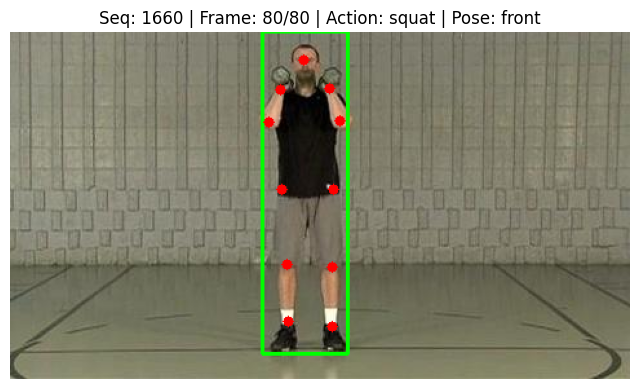

In [ ]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# 1. Find a 'squat' sequence with a 'front' viewpoint
target_actions = ['squat']
target_viewpoint = 'front'
sequence_id = None
action_name = None

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    # Extract Action
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    
    # Extract Viewpoint
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = viewpoint[0]
        
    if action in target_actions and viewpoint == target_viewpoint:
        sequence_id = label_file.split('.')[0]
        action_name = action
        break

if sequence_id is None:
    print(f"Could not find any sequence for {target_actions} with viewpoint '{target_viewpoint}'.")
else:
    print(f"Found Sequence: {sequence_id} | Action: {action_name} | Pose: {target_viewpoint}")
    
    # Load data for the found sequence
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    mat_data = sio.loadmat(mat_path)

    # Get the total number of frames from the loaded .mat file
    n_frames = mat_data['nframes'][0][0]

    for frame_idx in range(n_frames):
        # 1. Extract annotations for the current frame
        bbox = mat_data['bbox'][frame_idx]
        joints_x = mat_data['x'][frame_idx]
        joints_y = mat_data['y'][frame_idx]
        visibility = mat_data['visibility'][frame_idx]

        # 2. Load the corresponding image
        img_filename = f"{frame_idx + 1:06d}.jpg" 
        # Fallback for 4-digit formatting if needed
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        
        img = cv2.imread(img_path)
        if img is None:
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not load {img_path}. Skipping...")
                continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Draw Bounding Box and Keypoints
        cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        for i in range(len(joints_x)):
            if visibility[i] == 1:
                cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

        # 4. Display the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        # Also add the viewpoint to the matplotlib title
        plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {target_viewpoint}")
        plt.axis('off')
        
        plt.show()
        
        # Pause briefly so it plays like a video, then clear the cell for the next frame
        time.sleep(0.1) 
        clear_output(wait=True)

In [ ]:
# ... (Keep your imports and path setups the same) ...
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '1661'  # Change to your desired sequence ID 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

KeyboardInterrupt: 

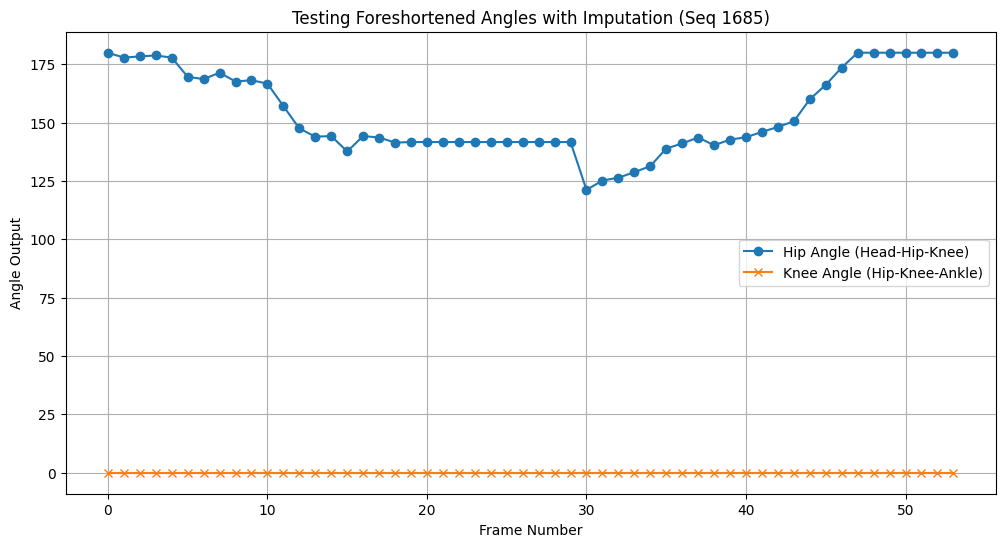

,frame,head_vel_y,f1_hip_head_ank,f2_hip_elb_ank,f3_hip_head_kne,f4_knee_ang
0,0,0.00,0.0,0.0,180.000,0.0
1,1,1.50,0.0,0.0,177.909,0.0
2,2,1.50,0.0,0.0,178.419,0.0
3,3,1.50,0.0,0.0,178.828,0.0
4,4,1.50,0.0,0.0,177.912,0.0
5,5,1.50,0.0,0.0,169.675,0.0
6,6,1.50,0.0,0.0,168.685,0.0
7,7,1.50,0.0,0.0,171.446,0.0
8,8,1.50,0.0,0.0,167.661,0.0
9,9,1.50,0.0,0.0,168.220,0.0


In [109]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '1685' # The highly occluded sequence

# --- Joint Indices ---
HEAD = 0; L_SHO = 1; R_SHO = 2; L_ELB = 3; R_ELB = 4; L_WRI = 5; R_WRI = 6
L_HIP = 7; R_HIP = 8; L_KNE = 9; R_KNE = 10; L_ANK = 11; R_ANK = 12

# --- Helper Functions ---
def get_ref_distance(mat_data, idx1, idx2):
    """Finds baseline limb length from the first frame both joints are visible."""
    n_frames = mat_data['nframes'][0][0]
    for f in range(n_frames):
        vis = mat_data['visibility'][f]
        if vis[idx1] == 1 and vis[idx2] == 1:
            x, y = mat_data['x'][f].astype(float), mat_data['y'][f].astype(float)
            return np.linalg.norm(np.array([x[idx1], y[idx1]]) - np.array([x[idx2], y[idx2]]))
    return 0.0 # Fallback if never visible

def calc_foreshortened_angle(p1, p2, p3, ref_d1, ref_d2):
    """Calculates angle using your sin(theta) + sin(alpha) length ratio method."""
    if ref_d1 == 0 or ref_d2 == 0: return 0.0
    
    cur_d1 = np.linalg.norm(np.array(p1) - np.array(p2))
    cur_d2 = np.linalg.norm(np.array(p2) - np.array(p3))
    
    # Clip to 1.0 to prevent math domain errors from noise making current > ref
    sin_theta = np.clip(cur_d1 / ref_d1, -1.0, 1.0)
    sin_alpha = np.clip(cur_d2 / ref_d2, -1.0, 1.0)
    
    theta = np.degrees(np.arcsin(sin_theta))
    alpha = np.degrees(np.arcsin(sin_alpha))
    return theta + alpha

# --- Load Data & Init References ---
mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# Pre-calculate baseline lengths for foreshortening
ref_head_hip = get_ref_distance(mat_data, HEAD, R_HIP)
ref_hip_ank  = get_ref_distance(mat_data, R_HIP, R_ANK)
ref_elb_hip  = get_ref_distance(mat_data, R_ELB, R_HIP)
ref_hip_kne  = get_ref_distance(mat_data, R_HIP, R_KNE)
ref_kne_ank  = get_ref_distance(mat_data, R_KNE, R_ANK)

# Tracking variables for imputation
last_known_pos = {i: [0.0, 0.0] for i in range(13)}
head_vel_y = 0.0
prev_head_y = None

features_list = []

# --- Frame Loop ---
for f in range(n_frames):
    jx, jy = mat_data['x'][f].astype(float), mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f].copy()
    
    # 1. Update velocities (Head serves as the proxy for torso movement)
    if vis[HEAD] == 1:
        if prev_head_y is not None:
            head_vel_y = jy[HEAD] - prev_head_y
        prev_head_y = jy[HEAD]
        last_known_pos[HEAD] = [jx[HEAD], jy[HEAD]]
        
    # 2. Impute Missing Joints
    for joint in range(13):
        if vis[joint] == 1:
            # Update last known if visible
            last_known_pos[joint] = [jx[joint], jy[joint]]
        else:
            # IMPUTATION LOGIC
            if joint in [L_ANK, R_ANK]:
                # Ankles don't move in squats: lock them to last known position
                jx[joint], jy[joint] = last_known_pos[joint]
            elif joint in [L_HIP, R_HIP, L_KNE, R_KNE]:
                # Hips/Knees move with the torso: apply head velocity to last known position
                last_known_pos[joint][1] += head_vel_y 
                jx[joint], jy[joint] = last_known_pos[joint]

    # Helper to format coordinates
    p = lambda idx: (jx[idx], jy[idx])

    # 3. Calculate Custom Features (Using Right side for this test)
    # Feature 1: Hip Angle (Head -> Hip -> Ankle)
    hip_ang_head_ank = calc_foreshortened_angle(p(HEAD), p(R_HIP), p(R_ANK), ref_head_hip, ref_hip_ank)
    
    # Feature 2: Hip Angle (Elbow -> Hip -> Ankle)
    hip_ang_elb_ank = calc_foreshortened_angle(p(R_ELB), p(R_HIP), p(R_ANK), ref_elb_hip, ref_hip_ank)
    
    # Feature 3: Hip Angle (Head -> Hip -> Knee) *Because ankle disappears
    hip_ang_head_kne = calc_foreshortened_angle(p(HEAD), p(R_HIP), p(R_KNE), ref_head_hip, ref_hip_kne)
    
    # Feature 4: Knee Angle (Hip -> Knee -> Ankle)
    knee_ang = calc_foreshortened_angle(p(R_HIP), p(R_KNE), p(R_ANK), ref_hip_kne, ref_kne_ank)
    
    features_list.append({
        'frame': f,
        'head_vel_y': head_vel_y,
        'f1_hip_head_ank': hip_ang_head_ank,
        'f2_hip_elb_ank': hip_ang_elb_ank,
        'f3_hip_head_kne': hip_ang_head_kne,
        'f4_knee_ang': knee_ang
    })

df_1685 = pd.DataFrame(features_list).round(3)

# --- 4. Plot to Verify ---
plt.figure(figsize=(12, 6))
plt.plot(df_1685['frame'], df_1685['f3_hip_head_kne'], label='Hip Angle (Head-Hip-Knee)', marker='o')
plt.plot(df_1685['frame'], df_1685['f4_knee_ang'], label='Knee Angle (Hip-Knee-Ankle)', marker='x')

plt.title(f"Testing Foreshortened Angles with Imputation (Seq {sequence_id})")
plt.xlabel("Frame Number")
plt.ylabel("Angle Output")
plt.grid(True)
plt.legend()
plt.show()

display(df_1685.head(25))

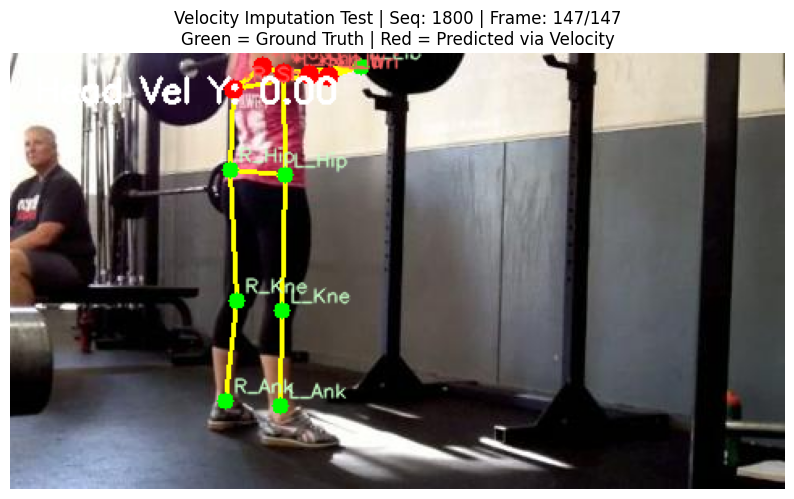

In [15]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1800' # The highly occluded sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
HEAD = 0; L_SHO = 1; R_SHO = 2; L_ELB = 3; R_ELB = 4; L_WRI = 5; R_WRI = 6
L_HIP = 7; R_HIP = 8; L_KNE = 9; R_KNE = 10; L_ANK = 11; R_ANK = 12

pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# --- Tracking Variables ---
# Store last known [x, y] for every joint. None means it hasn't appeared yet.
last_known_pos = {i: None for i in range(13)}
head_vel_y = 0.0
prev_head_y = None

for frame_idx in range(n_frames):
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx].astype(float)
    joints_y = mat_data['y'][frame_idx].astype(float)
    vis = mat_data['visibility'][frame_idx].copy()
    
    # 1. Update Head Velocity (Proxy for Torso Movement)
    if vis[HEAD] == 1:
        if prev_head_y is not None:
            head_vel_y = joints_y[HEAD] - prev_head_y # Positive = moving down in image coords
        prev_head_y = joints_y[HEAD]
        
    # 2. Impute Missing Joints
    is_predicted = {i: False for i in range(13)} # To track which ones we guessed
    
    for joint in range(13):
        if vis[joint] == 1:
            # Update last known position
            last_known_pos[joint] = [joints_x[joint], joints_y[joint]]
        else:
            # Joint is missing! Let's predict it.
            if last_known_pos[joint] is not None:
                is_predicted[joint] = True
                
                if joint in [L_ANK, R_ANK]:
                    # Ankles: Keep them exactly where they were (velocity = 0)
                    joints_x[joint] = last_known_pos[joint][0]
                    joints_y[joint] = last_known_pos[joint][1]
                else:
                    # Hips/Knees/Shoulders: Apply the head's Y-velocity to their last position
                    last_known_pos[joint][1] += head_vel_y
                    joints_x[joint] = last_known_pos[joint][0]
                    joints_y[joint] = last_known_pos[joint][1]
            else:
                # Edge Case: Joint is missing and has NEVER been seen yet. 
                # We can't predict it easily, leave it at 0.0
                pass

    # --- 3. Visualization ---
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines (only if both connected joints have a valid coordinate > 0)
    for (j1, j2) in skeleton:
        if (vis[j1] == 1 or is_predicted[j1]) and (vis[j2] == 1 or is_predicted[j2]):
            if joints_x[j1] > 0 and joints_x[j2] > 0:
                cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                         (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if joints_x[i] > 0 and joints_y[i] > 0: # Ensure it has a coordinate
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if is_predicted[i]:
                # Draw PREDICTED joints in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            elif vis[i] == 1:
                # Draw REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)

    # Info Text
    cv2.putText(img, f"Head Vel Y: {head_vel_y:.2f}", (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Velocity Imputation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted via Velocity")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [16]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- Joint Indices ---
HEAD = 0; L_SHO = 1; R_SHO = 2; L_ELB = 3; R_ELB = 4; L_WRI = 5; R_WRI = 6
L_HIP = 7; R_HIP = 8; L_KNE = 9; R_KNE = 10; L_ANK = 11; R_ANK = 12

pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

# List to store all our frames
all_imputed_data = []

# Loop exactly from 1659 to 1889
for seq_int in range(1659, 1890):
    sequence_id = f"{seq_int:04d}" # Formats '1659' to '1659'
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    # Check if the file exists (just in case some are missing from the dataset)
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify it is actually a squat video
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action not in ['squat', 'squats']: 
        continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: viewpoint = viewpoint[0]
    
    # Reset trackers for this new video
    last_known_pos = {i: None for i in range(13)}
    head_vel_y = 0.0
    prev_head_y = None
    
    for frame_idx in range(n_frames):
        jx = mat_data['x'][frame_idx].astype(float)
        jy = mat_data['y'][frame_idx].astype(float)
        vis = mat_data['visibility'][frame_idx].copy()
        
        # 1. Update Head Velocity
        if vis[HEAD] == 1:
            if prev_head_y is not None:
                head_vel_y = jy[HEAD] - prev_head_y
            prev_head_y = jy[HEAD]
            
        # 2. Impute Missing Joints
        # We will track a custom flag 'is_imputed' to know if this was a real point or a guessed one!
        is_imputed = {i: 0 for i in range(13)} 
        
        for joint in range(13):
            if vis[joint] == 1:
                # Joint is real! Save its position.
                last_known_pos[joint] = [jx[joint], jy[joint]]
            else:
                # Joint is missing! Predict it.
                if last_known_pos[joint] is not None:
                    is_imputed[joint] = 1 # Mark as guessed
                    
                    if joint in [L_ANK, R_ANK]:
                        # Ankles stay still
                        jx[joint] = last_known_pos[joint][0]
                        jy[joint] = last_known_pos[joint][1]
                    else:
                        # Hips/Knees move with head velocity
                        last_known_pos[joint][1] += head_vel_y
                        jx[joint] = last_known_pos[joint][0]
                        jy[joint] = last_known_pos[joint][1]
                else:
                    # If it was never seen, we leave it as 0.0
                    jx[joint] = 0.0
                    jy[joint] = 0.0

        # 3. Save the results for this frame
        frame_dict = {
            'sequence_id': sequence_id,
            'frame_num': frame_idx,
            'viewpoint': viewpoint,
            'head_velocity_y': round(head_vel_y, 3)
        }
        
        # Add the X, Y, and Imputed flag for all 13 joints
        for i in range(13):
            frame_dict[f'{pose_names[i]}_x'] = round(jx[i], 3)
            frame_dict[f'{pose_names[i]}_y'] = round(jy[i], 3)
            frame_dict[f'{pose_names[i]}_imputed'] = is_imputed[i] # 1 if predicted, 0 if ground truth
            
        all_imputed_data.append(frame_dict)

# Convert to Pandas and Save!
df_squats = pd.DataFrame(all_imputed_data)
df_squats.to_csv('squats_imputed_coords_1659_1889.csv', index=False)

print(f"Success! Processed {len(df_squats)} frames and saved to 'squats_imputed_coords_1659_1889.csv'.")
display(df_squats.head(10))

Success! Processed 21351 frames and saved to 'squats_imputed_coords_1659_1889.csv'.


,sequence_id,frame_num,viewpoint,head_velocity_y,Head_x,Head_y,Head_imputed,L_Sho_x,L_Sho_y,L_Sho_imputed,...,L_Kne_imputed,R_Kne_x,R_Kne_y,R_Kne_imputed,L_Ank_x,L_Ank_y,L_Ank_imputed,R_Ank_x,R_Ank_y,R_Ank_imputed
0,1659,0,left,0.000,241.333,79.333,0,0.0,0.0,0,...,0,238.000,212.667,0,250.667,242.0,0,243.333,257.333,0
1,1659,1,left,-0.667,241.333,78.667,0,0.0,0.0,0,...,0,237.333,212.000,0,250.667,242.0,0,242.667,256.667,0
2,1659,2,left,0.000,241.333,78.667,0,0.0,0.0,0,...,0,237.333,212.000,0,250.667,242.0,0,242.667,256.000,0
3,1659,3,left,-0.667,241.333,78.000,0,0.0,0.0,0,...,0,234.000,212.667,0,250.667,242.0,0,242.667,258.667,0
4,1659,4,left,-5.333,242.667,72.667,0,0.0,0.0,0,...,0,234.000,212.667,0,250.667,242.0,0,242.667,258.667,0
5,1659,5,left,-0.667,242.667,72.000,0,0.0,0.0,0,...,0,233.333,212.667,0,250.667,242.0,0,242.667,258.667,0
6,1659,6,left,0.667,242.667,72.667,0,0.0,0.0,0,...,0,232.667,212.667,0,250.667,242.0,0,243.333,258.667,0
7,1659,7,left,0.667,242.667,73.333,0,0.0,0.0,0,...,0,232.000,212.667,0,250.667,242.0,0,243.333,258.667,0
8,1659,8,left,0.000,242.667,73.333,0,0.0,0.0,0,...,0,232.000,212.667,0,250.667,242.0,0,243.333,258.667,0
9,1659,9,left,2.000,243.333,75.333,0,0.0,0.0,0,...,0,231.333,212.000,0,250.667,242.0,0,243.333,258.000,0


In [17]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- Joint Indices ---
HEAD = 0; L_SHO = 1; R_SHO = 2; L_ELB = 3; R_ELB = 4; L_WRI = 5; R_WRI = 6
L_HIP = 7; R_HIP = 8; L_KNE = 9; R_KNE = 10; L_ANK = 11; R_ANK = 12

pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

all_imputed_data = []

# Loop exactly from 1659 to 1889
for seq_int in range(1659, 1890):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify it is actually a squat video
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action not in ['squat', 'squats']: 
        continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: viewpoint = viewpoint[0]
    
    # Reset trackers for this new video
    last_known_pos = {i: None for i in range(13)}
    head_vel_y = 0.0
    prev_head_y = None
    
    for frame_idx in range(n_frames):
        jx = mat_data['x'][frame_idx].astype(float)
        jy = mat_data['y'][frame_idx].astype(float)
        vis = mat_data['visibility'][frame_idx].copy()
        
        # 1. Update Head Velocity
        if vis[HEAD] == 1:
            if prev_head_y is not None:
                head_vel_y = jy[HEAD] - prev_head_y
            prev_head_y = jy[HEAD]
            
        # 2. Impute Missing Joints seamlessly
        for joint in range(13):
            if vis[joint] == 1:
                last_known_pos[joint] = [jx[joint], jy[joint]]
            else:
                if last_known_pos[joint] is not None:
                    if joint in [L_ANK, R_ANK]:
                        # Ankles stay still
                        jx[joint], jy[joint] = last_known_pos[joint]
                    else:
                        # Hips/Knees move with head velocity
                        last_known_pos[joint][1] += head_vel_y
                        jx[joint], jy[joint] = last_known_pos[joint]
                else:
                    # If it was never seen, leave as 0.0
                    jx[joint], jy[joint] = 0.0, 0.0

        # 3. Build the row dictionary
        frame_dict = {
            'sequence_id': sequence_id,
            'frame_num': frame_idx,
            'viewpoint': viewpoint,
            'head_velocity_y': round(head_vel_y, 3)
        }
        
        # Add ONLY the X and Y coordinates
        for i in range(13):
            frame_dict[f'{pose_names[i]}_x'] = round(jx[i], 3)
            frame_dict[f'{pose_names[i]}_y'] = round(jy[i], 3)
            
        all_imputed_data.append(frame_dict)

# Convert to Pandas and Save
df_squats = pd.DataFrame(all_imputed_data)
df_squats.to_csv('squats_coords_1659_1889.csv', index=False)

print(f"Extraction complete. {len(df_squats)} frames saved to 'squats_coords_1659_1889.csv'.")
display(df_squats.head())

Extraction complete. 21351 frames saved to 'squats_coords_1659_1889.csv'.


,sequence_id,frame_num,viewpoint,head_velocity_y,Head_x,Head_y,L_Sho_x,L_Sho_y,R_Sho_x,R_Sho_y,...,R_Hip_x,R_Hip_y,L_Kne_x,L_Kne_y,R_Kne_x,R_Kne_y,L_Ank_x,L_Ank_y,R_Ank_x,R_Ank_y
0,1659,0,left,0.000,241.333,79.333,0.0,0.0,0.0,0.0,...,236.000,168.000,0.0,0.0,238.000,212.667,250.667,242.0,243.333,257.333
1,1659,1,left,-0.667,241.333,78.667,0.0,0.0,0.0,0.0,...,236.667,168.000,0.0,0.0,237.333,212.000,250.667,242.0,242.667,256.667
2,1659,2,left,0.000,241.333,78.667,0.0,0.0,0.0,0.0,...,237.333,168.667,0.0,0.0,237.333,212.000,250.667,242.0,242.667,256.000
3,1659,3,left,-0.667,241.333,78.000,0.0,0.0,0.0,0.0,...,238.667,169.333,0.0,0.0,234.000,212.667,250.667,242.0,242.667,258.667
4,1659,4,left,-5.333,242.667,72.667,0.0,0.0,0.0,0.0,...,239.333,170.000,0.0,0.0,234.000,212.667,250.667,242.0,242.667,258.667


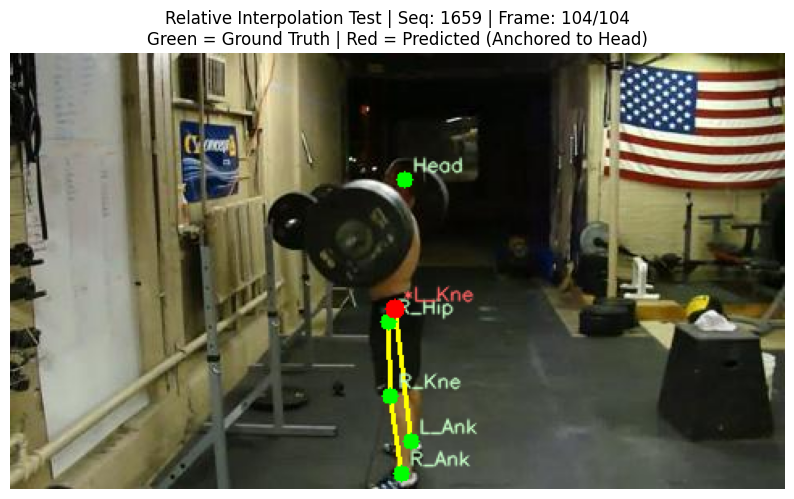

In [122]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1659' # A bowling sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
# 1. First, interpolate the Anchor (Head) perfectly across the whole video.
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# 2. Convert all other joints to be RELATIVE to the Head
for name in pose_names[1:]: # Skip the Head itself
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

# 3. Interpolate the RELATIVE coordinates (bridging the gap in local body space)
for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

# 4. Reconstruct the absolute coordinates by adding the moving Head back!
for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated relative-interpolated coordinates
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Relative Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Relative Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted (Anchored to Head)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

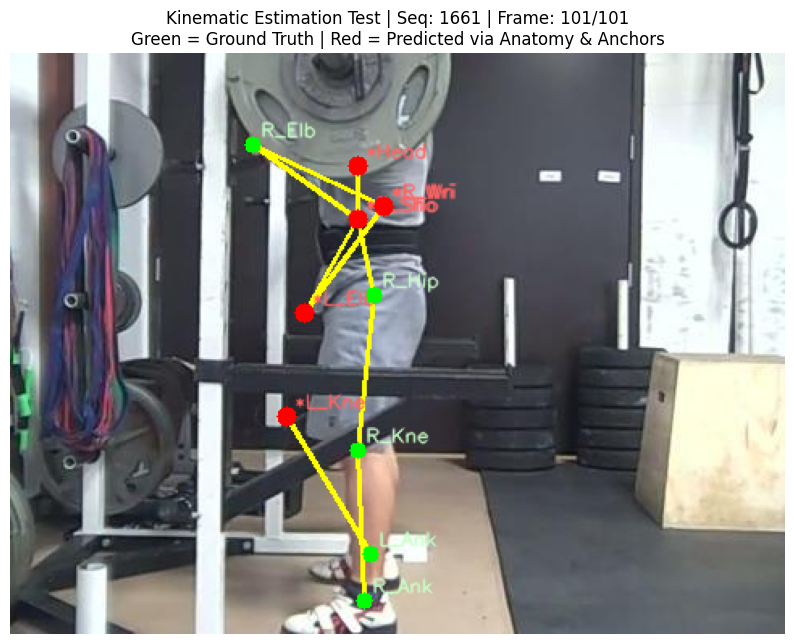

In [1]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1661' # The squat sequence with missing upper body

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: KINEMATIC ESTIMATION FOR PERPETUALLY MISSING JOINTS
# ==========================================
# If a joint NEVER appears, interpolation fails. We must estimate it 
# geometrically based on the Head and the Hip (using Anthropometric proportions).
for frame_idx in range(n_frames):
    head_y = df.at[frame_idx, 'Head_y']
    head_x = df.at[frame_idx, 'Head_x']
    
    # Try to find a valid Hip to use as the base of the torso
    hip_y = df.at[frame_idx, 'R_Hip_y'] if not pd.isna(df.at[frame_idx, 'R_Hip_y']) else df.at[frame_idx, 'L_Hip_y']
    hip_x = df.at[frame_idx, 'R_Hip_x'] if not pd.isna(df.at[frame_idx, 'R_Hip_x']) else df.at[frame_idx, 'L_Hip_x']
    
    if not pd.isna(head_y) and not pd.isna(hip_y):
        torso_length = hip_y - head_y
        
        # Estimate Shoulders (roughly 20% down the torso)
        if pd.isna(df.at[frame_idx, 'R_Sho_y']):
            df.at[frame_idx, 'R_Sho_y'] = head_y + (torso_length * 0.2)
            df.at[frame_idx, 'R_Sho_x'] = head_x 
        if pd.isna(df.at[frame_idx, 'L_Sho_y']):
            df.at[frame_idx, 'L_Sho_y'] = head_y + (torso_length * 0.2)
            df.at[frame_idx, 'L_Sho_x'] = head_x
            
        # Estimate Elbows (pointing down/back during a squat)
        if pd.isna(df.at[frame_idx, 'R_Elb_y']):
            df.at[frame_idx, 'R_Elb_y'] = df.at[frame_idx, 'R_Sho_y'] + (torso_length * 0.35)
            df.at[frame_idx, 'R_Elb_x'] = df.at[frame_idx, 'R_Sho_x'] - (torso_length * 0.2) 
        if pd.isna(df.at[frame_idx, 'L_Elb_y']):
            df.at[frame_idx, 'L_Elb_y'] = df.at[frame_idx, 'L_Sho_y'] + (torso_length * 0.35)
            df.at[frame_idx, 'L_Elb_x'] = df.at[frame_idx, 'L_Sho_x'] - (torso_length * 0.2)
            
        # Estimate Wrists (holding the barbell near the shoulders)
        if pd.isna(df.at[frame_idx, 'R_Wri_y']):
            df.at[frame_idx, 'R_Wri_y'] = df.at[frame_idx, 'R_Sho_y'] - (torso_length * 0.05)
            df.at[frame_idx, 'R_Wri_x'] = df.at[frame_idx, 'R_Sho_x'] + (torso_length * 0.1)
        if pd.isna(df.at[frame_idx, 'L_Wri_y']):
            df.at[frame_idx, 'L_Wri_y'] = df.at[frame_idx, 'L_Sho_y'] - (torso_length * 0.05)
            df.at[frame_idx, 'L_Wri_x'] = df.at[frame_idx, 'L_Sho_x'] + (torso_length * 0.1)

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED/ESTIMATED joints in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Kinematic Estimation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted via Anatomy & Anchors")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

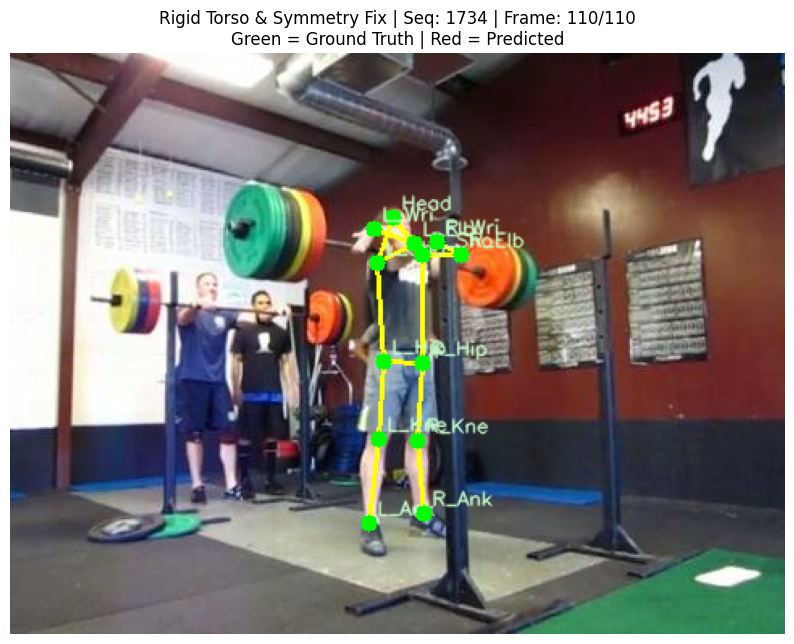

In [18]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1734' # The sequence with the "flying" head

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

# Bowl

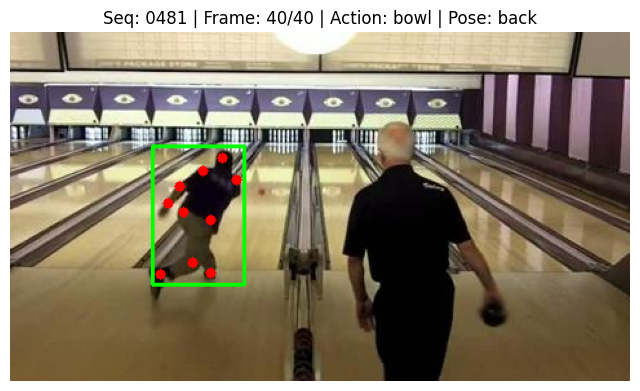

In [49]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# 1. Find a 'squat' sequence with a 'front' viewpoint
target_actions = ['bowl']
target_viewpoint = 'back'
sequence_id = None
action_name = None

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    # Extract Action
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    
    # Extract Viewpoint
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = viewpoint[0]
        
    if action in target_actions and viewpoint == target_viewpoint:
        sequence_id = label_file.split('.')[0]
        action_name = action
        break

if sequence_id is None:
    print(f"Could not find any sequence for {target_actions} with viewpoint '{target_viewpoint}'.")
else:
    print(f"Found Sequence: {sequence_id} | Action: {action_name} | Pose: {target_viewpoint}")
    
    # Load data for the found sequence
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    mat_data = sio.loadmat(mat_path)

    # Get the total number of frames from the loaded .mat file
    n_frames = mat_data['nframes'][0][0]

    for frame_idx in range(n_frames):
        # 1. Extract annotations for the current frame
        bbox = mat_data['bbox'][frame_idx]
        joints_x = mat_data['x'][frame_idx]
        joints_y = mat_data['y'][frame_idx]
        visibility = mat_data['visibility'][frame_idx]

        # 2. Load the corresponding image
        img_filename = f"{frame_idx + 1:06d}.jpg" 
        # Fallback for 4-digit formatting if needed
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        
        img = cv2.imread(img_path)
        if img is None:
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not load {img_path}. Skipping...")
                continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Draw Bounding Box and Keypoints
        cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        for i in range(len(joints_x)):
            if visibility[i] == 1:
                cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

        # 4. Display the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        # Also add the viewpoint to the matplotlib title
        plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {target_viewpoint}")
        plt.axis('off')
        
        plt.show()
        
        # Pause briefly so it plays like a video, then clear the cell for the next frame
        time.sleep(0.1) 
        clear_output(wait=True)

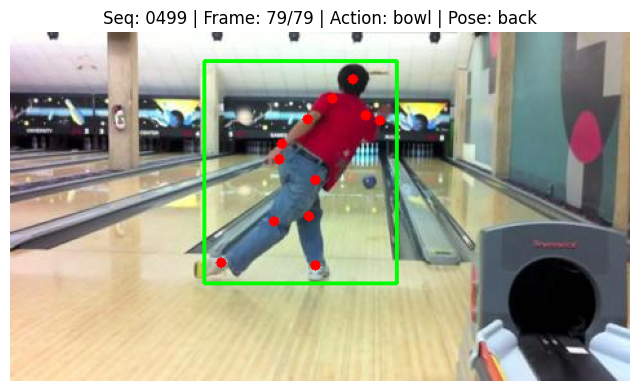

In [ ]:
# ... (Keep your imports and path setups the same) ...
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '0499'  # Change to your desired sequence ID 

# --- 'front' Pose Sequences (7 videos) ---
# 0542, 0543, 0551, 0618, 0624, 0662, 0697

# --- 'left' Pose Sequences (7 videos) ---
# 0547, 0553, 0554, 0625, 0626, 0627, 0628

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

In [52]:
import os
import scipy.io as sio

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# Dictionary to keep track of the counts
pose_counts = {}
total_bowl_videos = 0

# Loop from 481 to 700 (inclusive, so we use 701)
for seq_int in range(481, 701):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action is 'bowl'
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'bowl':
        continue
        
    total_bowl_videos += 1
    
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Increment our counter dictionary
    if viewpoint in pose_counts:
        pose_counts[viewpoint] += 1
    else:
        pose_counts[viewpoint] = 1

# Print the final results
print(f"Total 'bowl' videos found in range 0481-0700: {total_bowl_videos}\n")
print("Pose breakdown:")
for pose, count in sorted(pose_counts.items()):
    print(f" - {pose}: {count}")

Total 'bowl' videos found in range 0481-0700: 220

Pose breakdown:
 - back: 206
 - front: 7
 - left: 7


In [53]:
import os
import scipy.io as sio

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

front_ids = []
left_ids = []

# Loop from 481 to 700
for seq_int in range(481, 701):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action is 'bowl'
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'bowl':
        continue
        
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Categorize the sequence ID
    if viewpoint == 'front':
        front_ids.append(sequence_id)
    elif viewpoint == 'left':
        left_ids.append(sequence_id)

# Print the results clearly
print(f"--- 'front' Pose Sequences ({len(front_ids)} videos) ---")
print(", ".join(front_ids) if front_ids else "None found.")

print(f"\n--- 'left' Pose Sequences ({len(left_ids)} videos) ---")
print(", ".join(left_ids) if left_ids else "None found.")

--- 'front' Pose Sequences (7 videos) ---
0542, 0543, 0551, 0618, 0624, 0662, 0697

--- 'left' Pose Sequences (7 videos) ---
0547, 0553, 0554, 0625, 0626, 0627, 0628


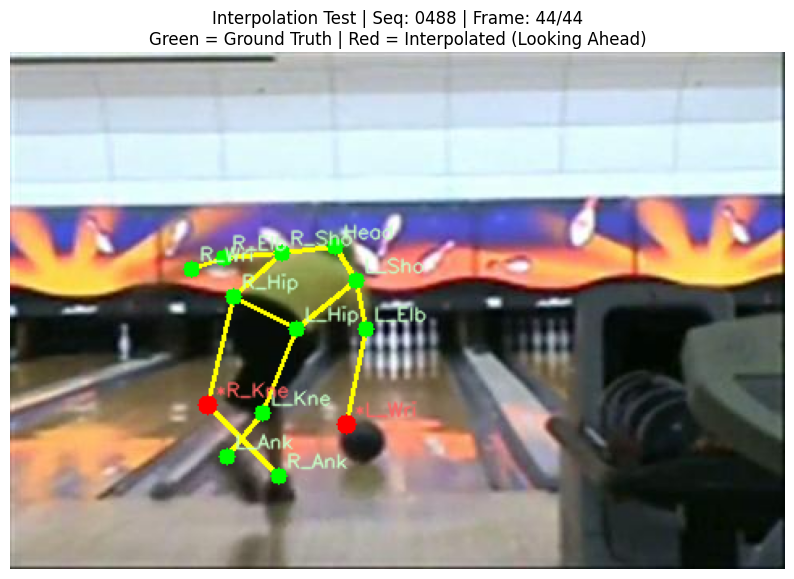

In [114]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '0488' # A bowling sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            # If missing, mark as Not a Number (NaN)
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: THE MAGIC - INTERPOLATE MISSING DATA
# ==========================================
# This looks at the point before it disappeared, and the point after it reappeared,
# and calculates the exact straight-line path between them frame-by-frame.
# 'limit_direction=both' handles edges (if it's missing at frame 0, it pulls the first known point backward).
df_interp = df.interpolate(method='linear', limit_direction='both')


# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated interpolated coordinates for this frame
    joints_x = [df_interp.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df_interp.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        # Check that we aren't drawing lines to 0.0 (in case a joint was NEVER visible in the whole video)
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Interpolated (Looking Ahead)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

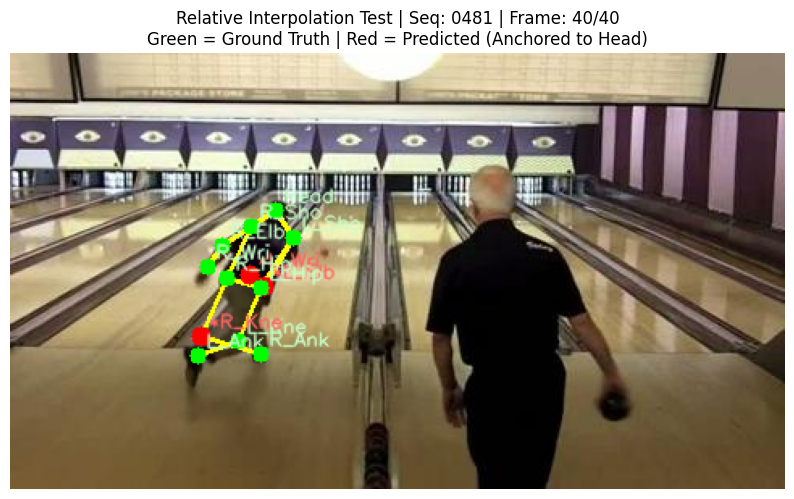

In [117]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '0481' # A bowling sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
# 1. First, interpolate the Anchor (Head) perfectly across the whole video.
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# 2. Convert all other joints to be RELATIVE to the Head
for name in pose_names[1:]: # Skip the Head itself
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

# 3. Interpolate the RELATIVE coordinates (bridging the gap in local body space)
for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

# 4. Reconstruct the absolute coordinates by adding the moving Head back!
for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated relative-interpolated coordinates
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Relative Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Relative Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted (Anchored to Head)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [ ]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- Joint Indices and Names ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

all_sequences_data = []
processed_count = 0

# Loop exactly from 481 to 700
for seq_int in range(481, 701):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify it is actually a bowl video
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'bowl': 
        continue
        
    n_frames = mat_data['nframes'][0][0]
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    
    # ==========================================
    # STEP 1: Extract Raw Data & Set Missing to NaN
    # ==========================================
    raw_data = []
    for f in range(n_frames):
        jx = mat_data['x'][f].astype(float)
        jy = mat_data['y'][f].astype(float)
        vis = mat_data['visibility'][f]
        
        row = {
            'sequence_id': sequence_id,
            'frame_num': f,
            'viewpoint': viewpoint
        }
        for i in range(13):
            if vis[i] == 1:
                row[f'{pose_names[i]}_x'] = jx[i]
                row[f'{pose_names[i]}_y'] = jy[i]
            else:
                row[f'{pose_names[i]}_x'] = np.nan
                row[f'{pose_names[i]}_y'] = np.nan
        raw_data.append(row)
        
    df_seq = pd.DataFrame(raw_data)

    # ==========================================
    # STEP 2: Anchor-Based Relative Interpolation
    # ==========================================
    # 1. Interpolate the Head (Anchor)
    df_seq['Head_x'] = df_seq['Head_x'].interpolate(method='linear', limit_direction='both')
    df_seq['Head_y'] = df_seq['Head_y'].interpolate(method='linear', limit_direction='both')
    
    # Fallback: If Head was NEVER visible in the whole video, fill with 0 to prevent crashes
    df_seq['Head_x'] = df_seq['Head_x'].fillna(0.0)
    df_seq['Head_y'] = df_seq['Head_y'].fillna(0.0)

    # 2. Convert to Relative & Interpolate
    for name in pose_names[1:]:
        # To relative
        df_seq[f'{name}_rel_x'] = df_seq[f'{name}_x'] - df_seq['Head_x']
        df_seq[f'{name}_rel_y'] = df_seq[f'{name}_y'] - df_seq['Head_y']
        
        # Interpolate relative
        df_seq[f'{name}_rel_x'] = df_seq[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df_seq[f'{name}_rel_y'] = df_seq[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        
        # Reconstruct absolute
        df_seq[f'{name}_x'] = df_seq[f'{name}_rel_x'] + df_seq['Head_x']
        df_seq[f'{name}_y'] = df_seq[f'{name}_rel_y'] + df_seq['Head_y']

        # Final Fallback: If a joint was NEVER visible in the video, fill the remaining NaNs with 0.0
        df_seq[f'{name}_x'] = df_seq[f'{name}_x'].fillna(0.0)
        df_seq[f'{name}_y'] = df_seq[f'{name}_y'].fillna(0.0)

    # ==========================================
    # STEP 3: Keep Only Needed Columns & Round
    # ==========================================
    # We drop the temporary '_rel_' columns to keep the CSV clean
    columns_to_keep = ['sequence_id', 'frame_num', 'viewpoint']
    for name in pose_names:
        columns_to_keep.extend([f'{name}_x', f'{name}_y'])
        
    df_seq_clean = df_seq[columns_to_keep].copy()
    
    # Round all coordinates to 3 decimal places
    for col in df_seq_clean.columns:
        if col not in ['sequence_id', 'frame_num', 'viewpoint']:
            df_seq_clean[col] = df_seq_clean[col].round(3)

    all_sequences_data.append(df_seq_clean)
    processed_count += 1

# ==========================================
# STEP 4: Combine & Save!
# ==========================================
df_final_bowl = pd.concat(all_sequences_data, ignore_index=True)
df_final_bowl.to_csv('bowl_coords_481_700.csv', index=False)

print(f"Awesome! Processed {processed_count} bowling videos.")
print(f"Saved {len(df_final_bowl)} cleanly interpolated frames to 'bowl_coords_481_700.csv'.")
display(df_final_bowl.head())

Awesome! Processed 220 bowling videos.
Saved 12626 cleanly interpolated frames to 'bowl_interpolated_coords_481_700.csv'.


,sequence_id,frame_num,viewpoint,Head_x,Head_y,L_Sho_x,L_Sho_y,R_Sho_x,R_Sho_y,L_Elb_x,...,R_Hip_x,R_Hip_y,L_Kne_x,L_Kne_y,R_Kne_x,R_Kne_y,L_Ank_x,L_Ank_y,R_Ank_x,R_Ank_y
0,0481,0,back,137.005,99.579,145.693,127.649,99.579,119.629,151.708,...,88.218,181.114,128.317,240.594,101.584,237.252,112.946,241.262,100.248,242.599
1,0481,1,back,138.342,101.584,146.361,128.985,100.916,120.297,151.708,...,88.886,181.114,128.317,239.257,102.252,235.248,114.282,243.267,101.584,244.604
2,0481,2,back,139.678,103.589,147.030,129.653,102.921,120.965,152.376,...,89.554,181.782,128.317,238.589,104.926,239.926,115.619,245.272,102.921,246.609
3,0481,3,back,141.015,106.262,147.698,130.990,109.604,122.970,154.381,...,90.891,182.450,128.317,237.252,106.262,238.589,116.955,247.946,104.257,249.282
4,0481,4,back,142.351,108.267,148.366,131.658,110.941,124.307,155.050,...,92.228,183.119,128.985,239.257,107.599,237.252,118.292,249.950,105.594,251.287


# Pushup

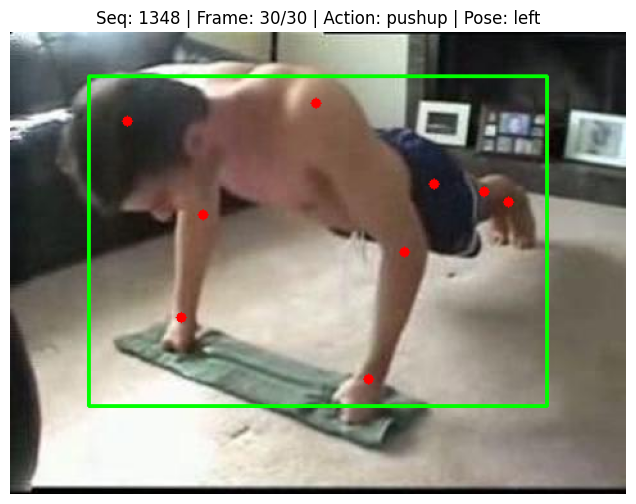

In [21]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# 1. Find a 'squat' sequence with a 'front' viewpoint
target_actions = ['pushup']
target_viewpoint = 'left'
sequence_id = None
action_name = None

for label_file in os.listdir(LABELS_DIR):
    if not label_file.endswith('.mat'): continue
    
    mat_data = sio.loadmat(os.path.join(LABELS_DIR, label_file))
    
    # Extract Action
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    
    # Extract Viewpoint
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = viewpoint[0]
        
    if action in target_actions and viewpoint == target_viewpoint:
        sequence_id = label_file.split('.')[0]
        action_name = action
        break

if sequence_id is None:
    print(f"Could not find any sequence for {target_actions} with viewpoint '{target_viewpoint}'.")
else:
    print(f"Found Sequence: {sequence_id} | Action: {action_name} | Pose: {target_viewpoint}")
    
    # Load data for the found sequence
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    mat_data = sio.loadmat(mat_path)

    # Get the total number of frames from the loaded .mat file
    n_frames = mat_data['nframes'][0][0]

    for frame_idx in range(n_frames):
        # 1. Extract annotations for the current frame
        bbox = mat_data['bbox'][frame_idx]
        joints_x = mat_data['x'][frame_idx]
        joints_y = mat_data['y'][frame_idx]
        visibility = mat_data['visibility'][frame_idx]

        # 2. Load the corresponding image
        img_filename = f"{frame_idx + 1:06d}.jpg" 
        # Fallback for 4-digit formatting if needed
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        
        img = cv2.imread(img_path)
        if img is None:
            img_filename = f"{frame_idx + 1:04d}.jpg"
            img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Could not load {img_path}. Skipping...")
                continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Draw Bounding Box and Keypoints
        cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
        for i in range(len(joints_x)):
            if visibility[i] == 1:
                cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

        # 4. Display the frame
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        # Also add the viewpoint to the matplotlib title
        plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {target_viewpoint}")
        plt.axis('off')
        
        plt.show()
        
        # Pause briefly so it plays like a video, then clear the cell for the next frame
        time.sleep(0.1) 
        clear_output(wait=True)

In [63]:
import os
import scipy.io as sio

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# Dictionary to keep track of the counts
pose_counts = {}
total_bowl_videos = 0

for seq_int in range(1348, 1558):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action 
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'pushup':
        continue
        
    total_bowl_videos += 1
    
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Increment our counter dictionary
    if viewpoint in pose_counts:
        pose_counts[viewpoint] += 1
    else:
        pose_counts[viewpoint] = 1

# Print the final results
print(f"Total 'pushup' videos found : {total_bowl_videos}\n")
print("Pose breakdown:")
for pose, count in sorted(pose_counts.items()):
    print(f" - {pose}: {count}")

Total 'pushup' videos found : 210

Pose breakdown:
 - back: 1
 - front: 37
 - left: 83
 - right: 89


In [65]:
import os
import scipy.io as sio

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

front_ids = []
back_ids = []


for seq_int in range(1348, 1558 ):
    sequence_id = f"{seq_int:04d}" 
    mat_path = os.path.join(LABELS_DIR, f"{sequence_id}.mat")
    
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Verify the action is 'bowl'
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action != 'pushup':
        continue
        
    # Extract the Viewpoint/Pose
    viewpoint = mat_data.get('pose', ['Unknown'])[0]
    if isinstance(viewpoint, (list, np.ndarray)) and len(viewpoint) > 0: 
        viewpoint = str(viewpoint[0])
    else:
        viewpoint = str(viewpoint)
        
    # Categorize the sequence ID
    if viewpoint == 'front':
        front_ids.append(sequence_id)
    elif viewpoint == 'back':
        back_ids.append(sequence_id)

# Print the results clearly
print(f"--- 'front' Pose Sequences ({len(front_ids)} videos) ---")
print(", ".join(front_ids) if front_ids else "None found.")

print(f"\n--- 'back' Pose Sequences ({len(back_ids)} videos) ---")
print(", ".join(back_ids) if back_ids else "None found.")

--- 'front' Pose Sequences (37 videos) ---
1349, 1355, 1356, 1357, 1358, 1396, 1397, 1423, 1432, 1442, 1445, 1452, 1453, 1457, 1474, 1480, 1492, 1497, 1499, 1501, 1507, 1508, 1511, 1512, 1519, 1522, 1525, 1528, 1532, 1534, 1536, 1542, 1543, 1544, 1546, 1555, 1556

--- 'back' Pose Sequences (1 videos) ---
1399


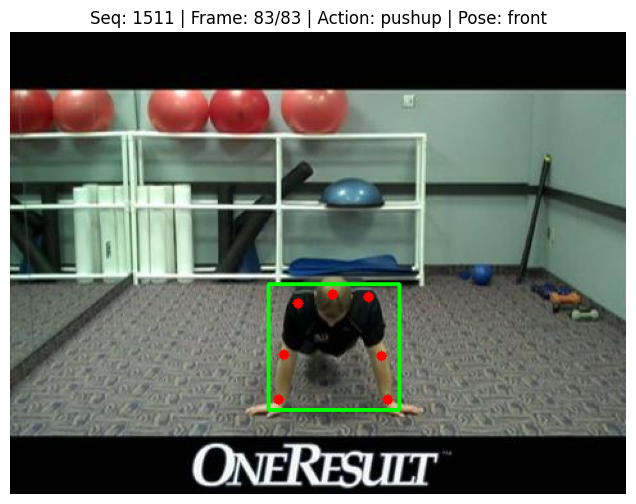

In [ ]:
 # ... (Keep your imports and path setups the same) ...
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '1511'  # Change to your desired sequence ID 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

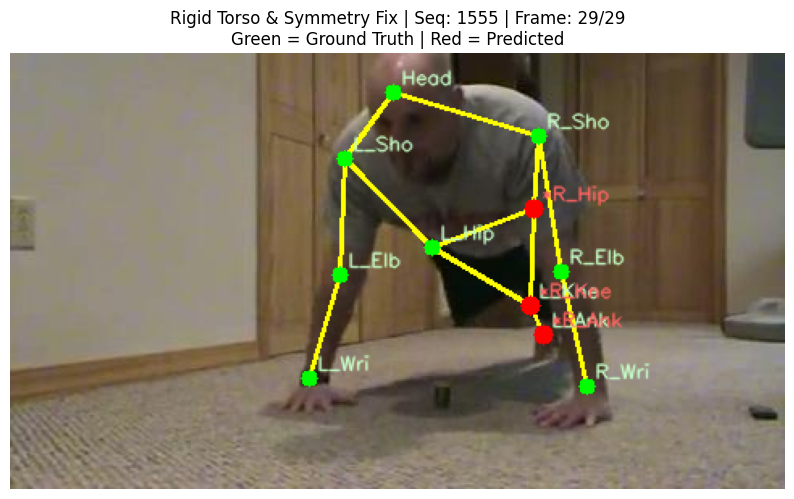

In [ ]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1555' # The sequence with the "flying" head 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

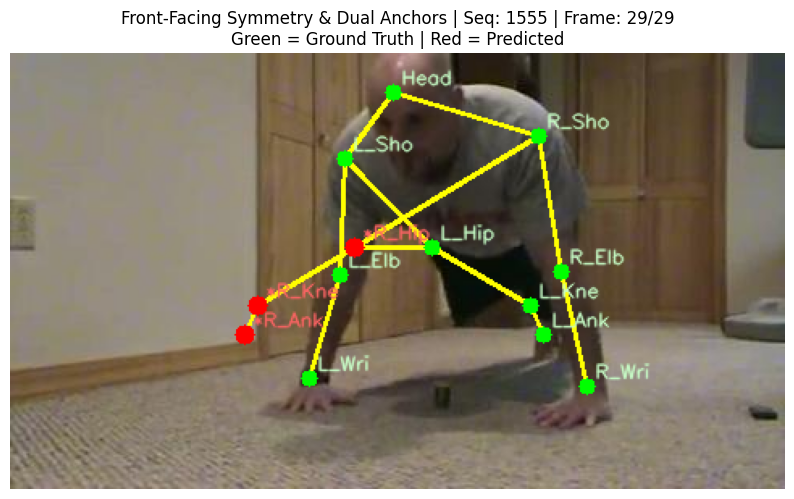

In [87]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1555' # Pushup sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FRONT-FACING MIRROR SYMMETRY
# ==========================================
# Interpolate the Head first so we can use it as a mirror axis
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

for f in range(n_frames):
    head_x = df.at[f, 'Head_x']
    
    # Mirror missing joints across the vertical axis of the head
    for joint in ['Sho', 'Elb', 'Wri', 'Hip', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = head_x - (df.at[f, r_x] - head_x) # Mirror Left
            
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = head_x + (head_x - df.at[f, l_x]) # Mirror Right

# ==========================================
# STEP 2: DUAL-ANCHOR RELATIVE INTERPOLATION
# ==========================================
upper_joints = ['L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri']
lower_joints = ['L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

# 1. Establish the Lower Body Anchor (Mid-Hip)
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1).interpolate(method='linear', limit_direction='both')
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1).interpolate(method='linear', limit_direction='both')

# 2. Anchor UPPER body to the HEAD
for name in upper_joints: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# 3. Anchor LOWER body to the HIPS (Prevents feet/knees from sinking with the head)
for name in lower_joints:
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Mid_Hip_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Mid_Hip_y']
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Mid_Hip_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Mid_Hip_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Front-Facing Symmetry & Dual Anchors | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

In [ ]:
import os
import scipy.io as sio
import numpy as np
import pandas as pd

DATASET_ROOT = './Penn_Action/Penn_Action'
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

# Columns we want to keep for the final CSV export
final_columns = []
for name in pose_names:
    final_columns.append(f'{name}_x')
    final_columns.append(f'{name}_y')

# This list will hold the DataFrames for all 200+ videos
all_pushup_data = []

start_seq = 1348
end_seq = 1557

print(f"Starting batch process for sequences {start_seq} to {end_seq}...")

for seq_num in range(start_seq, end_seq + 1):
    sequence_id = f"{seq_num:04d}"
    mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
    
    # Skip if the .mat file doesn't exist
    if not os.path.exists(mat_path):
        continue
        
    mat_data = sio.loadmat(mat_path)
    
    # Double check to ensure it's actually a pushup video
    action = mat_data['action'][0] if isinstance(mat_data['action'], (list, np.ndarray)) else mat_data['action']
    if action not in ['pushup', 'pushups']: 
        continue
        
    n_frames = mat_data['nframes'][0][0]

    # ==========================================
    # STEP 1: LOAD ALL FRAMES 
    # ==========================================
    raw_data = []
    for f in range(n_frames):
        jx = mat_data['x'][f].astype(float)
        jy = mat_data['y'][f].astype(float)
        vis = mat_data['visibility'][f]
        
        row = {}
        for i in range(13):
            if vis[i] == 1:
                row[f'{pose_names[i]}_x'] = jx[i]
                row[f'{pose_names[i]}_y'] = jy[i]
            else:
                row[f'{pose_names[i]}_x'] = np.nan
                row[f'{pose_names[i]}_y'] = np.nan
        raw_data.append(row)

    df = pd.DataFrame(raw_data)

    # ==========================================
    # STEP 1.5: FRONT-FACING MIRROR SYMMETRY
    # ==========================================
    df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
    df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

    for f in range(n_frames):
        head_x = df.at[f, 'Head_x']
        
        for joint in ['Sho', 'Elb', 'Wri', 'Hip', 'Kne', 'Ank']:
            r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
            l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
            
            if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
                df.at[f, l_y] = df.at[f, r_y]
                df.at[f, l_x] = head_x - (df.at[f, r_x] - head_x) 
                
            elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
                df.at[f, r_y] = df.at[f, l_y]
                df.at[f, r_x] = head_x + (head_x - df.at[f, l_x]) 

    # ==========================================
    # STEP 2: DUAL-ANCHOR RELATIVE INTERPOLATION
    # ==========================================
    upper_joints = ['L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri']
    lower_joints = ['L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

    df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1).interpolate(method='linear', limit_direction='both')
    df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1).interpolate(method='linear', limit_direction='both')

    for name in upper_joints: 
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

    for name in lower_joints:
        df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Mid_Hip_x']
        df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Mid_Hip_y']
        df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')
        df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Mid_Hip_x']
        df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Mid_Hip_y']

    # ==========================================
    # STEP 3: PREPARE FOR CONCATENATION
    # ==========================================
    # Filter out the temporary calculation columns
    df_export = df[final_columns].copy()
    
    # Add Sequence_ID and Frame columns to the very front
    df_export.insert(0, 'Frame', df_export.index + 1)
    df_export.insert(0, 'Sequence_ID', sequence_id)
    
    # Round coordinates to 3 decimals to keep the CSV clean
    df_export = df_export.round(3)
    
    # Append this processed sequence to our master list
    all_pushup_data.append(df_export)
    
    # Print progress
    if seq_num % 20 == 0:
        print(f"Processed up to sequence {sequence_id}...")

# ==========================================
# STEP 4: COMBINE AND EXPORT
# ==========================================
print("\nCombining all sequences into a single file...")

# Concatenate all DataFrames into one massive dataset
final_df = pd.concat(all_pushup_data, ignore_index=True)

# Export to a single CSV
final_csv_name = 'pushups_coords_1348_1557.csv'
final_df.to_csv(final_csv_name, index=False)

print(f"Success! Saved {len(final_df)} total frames across {len(all_pushup_data)} sequences to '{final_csv_name}'.")
display(final_df.head())

Starting batch process for sequences 1348 to 1557...
Processed up to sequence 1360...
Processed up to sequence 1380...
Processed up to sequence 1400...
Processed up to sequence 1420...
Processed up to sequence 1440...
Processed up to sequence 1460...
Processed up to sequence 1480...
Processed up to sequence 1500...
Processed up to sequence 1520...
Processed up to sequence 1540...

Combining all sequences into a single file...
Success! Saved 10453 total frames across 210 sequences to 'all_pushups_interpolated_1348_1557.csv'.


,Sequence_ID,Frame,Head_x,Head_y,L_Sho_x,L_Sho_y,R_Sho_x,R_Sho_y,L_Elb_x,L_Elb_y,...,R_Hip_x,R_Hip_y,L_Kne_x,L_Kne_y,R_Kne_x,R_Kne_y,L_Ank_x,L_Ank_y,R_Ank_x,R_Ank_y
0,1348,1,78.0,46.5,-76.5,48.0,232.5,48.0,154.5,129.0,...,325.5,103.5,-208.5,124.5,364.5,124.5,-232.5,121.5,388.5,121.5
1,1348,2,75.0,63.0,-81.0,58.5,231.0,58.5,154.5,135.0,...,325.5,108.0,-214.5,129.0,364.5,129.0,-238.5,121.5,388.5,121.5
2,1348,3,84.0,84.0,-61.5,70.5,229.5,70.5,-145.5,171.0,...,325.5,112.5,-195.0,130.5,363.0,130.5,-220.5,121.5,388.5,121.5
3,1348,4,81.0,100.5,-66.0,84.0,228.0,84.0,-157.5,175.5,...,327.0,123.0,-199.5,133.5,361.5,133.5,-225.0,121.5,387.0,121.5
4,1348,5,76.5,118.5,-72.0,103.5,225.0,103.5,-171.0,180.0,...,327.0,127.5,-207.0,135.0,360.0,135.0,-234.0,123.0,387.0,123.0


# PullUP


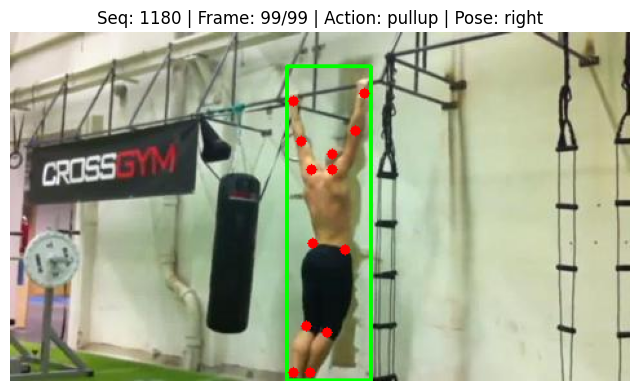

In [103]:
 # ... (Keepss your imports and path setups the same) ...
DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')
sequence_id = '1180'  # Change to your desired sequence ID 

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)

# Get the total number of frames from the loaded .mat file
n_frames = mat_data['nframes'][0][0]

# Extract Action
action_name = mat_data['action'][0]
if isinstance(action_name, (list, np.ndarray)):
    action_name = action_name[0]

# Extract Viewpoint/Pose (front, back, left, right)
viewpoint = mat_data.get('pose', ['Unknown'])[0]
if isinstance(viewpoint, (list, np.ndarray)):
    if len(viewpoint) > 0:
        viewpoint = viewpoint[0]
    else:
        viewpoint = 'Unknown'

for frame_idx in range(n_frames):
    # 1. Extract annotations for the current frame
    bbox = mat_data['bbox'][frame_idx]
    joints_x = mat_data['x'][frame_idx]
    joints_y = mat_data['y'][frame_idx]
    visibility = mat_data['visibility'][frame_idx]

    # 2. Load the corresponding image
    img_filename = f"{frame_idx + 1:06d}.jpg" 
    # Fallback for 4-digit formatting if needed: img_filename = f"{frame_idx + 1:04d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}. Skipping...")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. Draw Bounding Box and Keypoints
    cv2.rectangle(img, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 0), 2)
    for i in range(len(joints_x)):
        if visibility[i] == 1:
            cv2.circle(img, (int(joints_x[i]), int(joints_y[i])), 4, (255, 0, 0), -1)

    # Write the Viewpoint on the image itself (Top Left Corner)
    # text_to_display = f"Viewpoint: {viewpoint}"
    # cv2.putText(img, text_to_display, (15, 35), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2, cv2.LINE_AA)

    # 4. Display the frame
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    # Also add the viewpoint to the matplotlib title
    plt.title(f"Seq: {sequence_id} | Frame: {frame_idx + 1}/{n_frames} | Action: {action_name} | Pose: {viewpoint}")
    plt.axis('off')
    
    plt.show()
    
    # Pause briefly so it plays like a video, then clear the cell for the next frame
    time.sleep(0.1) 
    clear_output(wait=True)

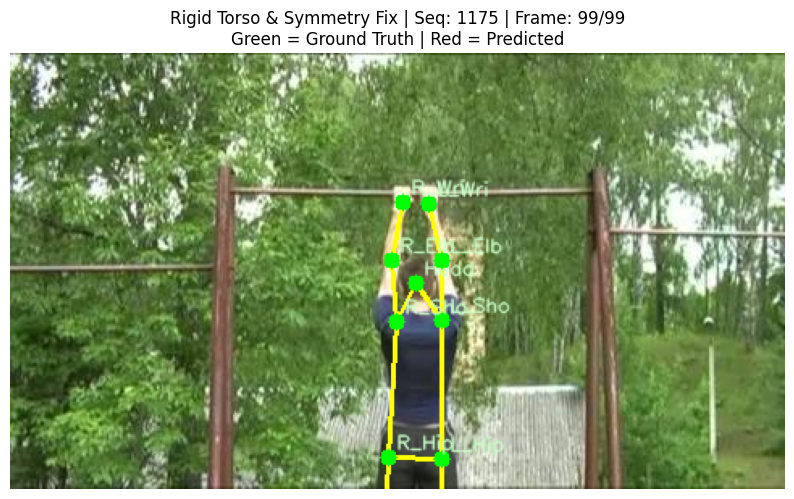

In [112]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1175' # The sequence with the "flying" head

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

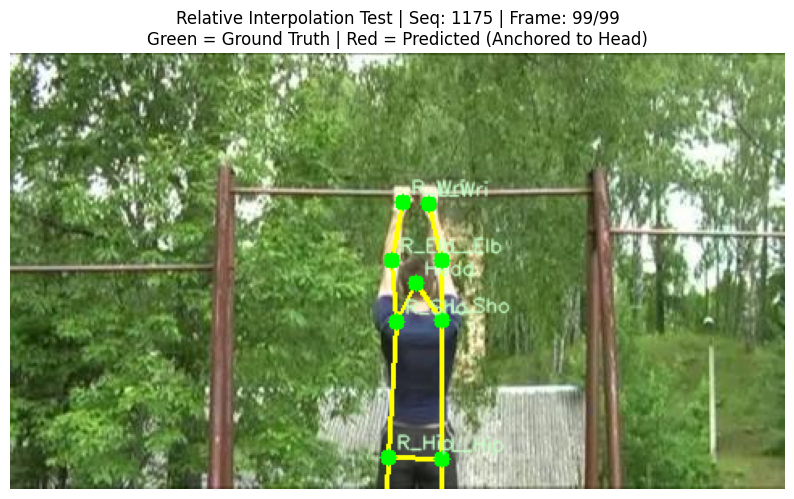

In [115]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = './Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1175' # A bowling sequence

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES AND REPLACE MISSING WITH 'NaN'
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
# 1. First, interpolate the Anchor (Head) perfectly across the whole video.
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# 2. Convert all other joints to be RELATIVE to the Head
for name in pose_names[1:]: # Skip the Head itself
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

# 3. Interpolate the RELATIVE coordinates (bridging the gap in local body space)
for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

# 4. Reconstruct the absolute coordinates by adding the moving Head back!
for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    # Grab the newly calculated relative-interpolated coordinates
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    # Load Image
    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw Skeleton lines 
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    # Draw Joints
    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                # PREDICTED joints via Relative Interpolation in RED
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                # REAL joints in GREEN
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Relative Interpolation Test | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted (Anchored to Head)")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)